# Visión por Computador - Práctica 2 - Deep Learning en Computer Vision

#### 15 puntos   |   Fecha de entrega: 7 de Diciembre, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2526.ugr.es/

### Estudiante: <mark>Jaime Corzo Galdó</mark>



## Normas de desarrollo y entrega de la práctica

1. Para este trabajo, al igual que para los demás, se debe presentar código, resultados, discusión de los mismos, y presentación y análisis del trabajo realizado, todo integrado en el propio Google Colab Notebook (es decir, no se entrega ninguna memoria separada en `.pdf` ni ningún código `.py`). Se recuerda que código y resultados sin informe explicativo no puntúa. Resulta también fundamental recordar que solo se acepta la entrega de ficheros `.ipynb` (no resulta válido entregar un fichero `.py`).

2. En relación con el punto anterior, se recuerda que se proporciona un Notebook, denominado `Ejemplo_Otsu.ipynb`, que muestra un ejemplo de respuesta y solución a un potencial ejercicio. El propósito de este Notebook es servir de referencia al alumnado acerca de cómo responder los ejercicios planteados. Véase que, por ejemplo, en aras de diferenciar con facilidad enunciados y respuestas, estas últimas se presentan en otro color (azul, en ese caso).

3. El diseño de celdas del documento debe ser respetado. Es decir, no se puede modificar el orden de los ejercicios o alterar la estructura del Notebook, de forma que dificulte localizar los contenidos. Aunque sí se puede, por ejemplo, crear nuevas subsecciones dentro de las secciones ya existentes para estructurar y organizar con más claridad las respuestas, así como para incluir los experimentos extra que se deseen.

4. Tal y como se muestra en `Ejemplo_Otsu.ipynb`, no hay ningún problema en emplear técnicas de IA generativa (como ChatGPT o Gemini) para crear el código de los distintos ejercicios o para enriquecer el análisis y descripción del trabajo realizado (aunque, obvia decirlo, su uso no es obligatorio). Pero, en caso de usarse, sí se debe aclarar de qué modo se ha usado la IA, con qué objetivo, y se debe demostrar que se entiende perfectamente lo que se ha hecho.

5. Solo se entregará el fichero `.ipynb` (incorporando código, resultados, y explicación del trabajo realizado y los resultados obtenidos) y no se enviarán las imágenes empleadas. El path para la lectura de imágenes, o cualquier otro fichero de entrada, debe ser siempre “/content/drive/My Drive/images/nombre_fichero”.

6. El código deberá  presentarse adecuadamente comentado y con los resultados obtenidos en cada apartado, junto con la presentación del trabajo realizado y la discusión y análisis de los resultados obtenidos. Es importante reiterar que la entrega de código sin informe explicativo o valoraciones no puntúa. Por otro lado, el código debe ir comentado en comentarios en celdas de código, mientras que el análisis y discusión, tanto del trabajo realizado como de los resultados obtenidos, debe ir en celdas de texto.






### Materiales de Apoyo

En caso de que el alumnado tenga dudas sobre Python, OpenCV o el uso de Google Colab, se recuerda que en PRADO hay materiales de apoyo (https://pradogrado2526.ugr.es/mod/folder/view.php?id=95307):
-  Introducción a Python: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/1.%20Introduccion%20a%20Python.pdf
- Introducción a NumPy, Matplotlib y Scikit-learn: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/2.%20Introducción%20a%20Numpy%20Matplotlib%20y%20sklearn.pdf
- Notebook con toda la información anterior (y más cosas): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_Python.ipynb
- Ejercicios y ejemplos de repaso: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/3.%20Ejercicios%20y%20ejemplos%20de%20repaso.pdf
- Fundamentos de Python para lectura, visualización y manipulación de imágenes: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/4.%20Fundamentos%20de%20Python%20para%20manipulacion%20de%20imagenes.pdf (y Notebook asociado: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_fundamentos_imagenes.ipynb)
- Ideas sobre cómo redactar un documento académico-científico (útil para saber cómo documentar las respuestas a los ejercicios, el Notebook en su conjunto, y la memoria del proyecto final o de un TFG/TFM): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Algunas%20ideas%20sobre%20cómo%20elaborar%20un%20informe%20académico-científico.pdf
- Ejemplo de respuesta a un hipotético ejercicio sobre el algoritmo de umbralización de Otsu: https://pradogrado2526.ugr.es/pluginfile.php/243164/mod_folder/content/0/Ejemplo_Otsu.ipynb

<font color='blue'>El objetivo de esta práctica es aprender a diseñar, implementar, entrenar y utilizar (es decir, aplicar en inferencia) redes neuronales convolucionales en tareas de visión por computador (clasificación y regresión en imágenes) usando fastai (https://docs.fast.ai/).

<font color='blue'>Se proporciona una guía de ayuda (`P2_HG.ipynb`) para, entre otras cosas, saber cómo:
1. realizar funciones básicas de lectura de datos, entrenamiento y optimización;
2. crear gráficos para la evolución del error de clasificación en
los conjuntos de entrenamiento y validación;
3. y calcular el error de clasificación en el conjunto de prueba.

In [ ]:
# The first thing we should do is to apply hardware acceleration via GPU. So, we have to go to Editar - Configuracion del Cuaderno - Acelerador por Hardware GPU

# Now we SET UP Fastai
!pip install -Uqq fastbook
!pip install nbdev
import fastbook
fastbook.setup_book()
import fastai
import fastcore
print(f'fastcore version {fastcore.__version__} installed')
print(f'fastai version {fastai.__version__} installed')
from nbdev.showdoc import *
from fastai.vision.all import *

fastcore version 1.8.16 installed
fastai version 2.8.5 installed


In [ ]:
# Function to display evaluation metrics
# Developed by Ignacio Oguiza: https://forums.fast.ai/t/plotting-metrics-after-learning/69937

@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()



---



---



---



# <font color='blue'>**Ejercicio 1: BaseNet en 50 clases de CIFAR100 (5 puntos)**





## <font color='blue'> Creación, entrenamiento y validación del modelo (4 puntos)

<font color='blue'>**Dataset:**
En este ejercicio, trabajaremos con parte del conjunto de datos $\textit{CIFAR100}$ (https://www.cs.toronto.edu/~kriz/cifar.html). Este conjunto de datos consta de $60000$ imágenes en color de $32\times32\times3$ (RGB) que representan $100$ clases diferentes ($600$ imágenes por clase). Hay $50000$ imágenes para entrenamiento y $10000$ para test. No obstante, para el desarrollo del ejercicio solo consideraremos $50$ clases (de $100$). Por lo tanto, el conjunto de entrenamiento tendrá $25000$ imágenes y el conjunto de prueba $5000$ imágenes. Los alumnos deben emplear el $10\%$ del conjunto de entrenamiento para  validación.

<font color='blue'>**Modelo BaseNet:**
Comenzamos creando un modelo base llamado *BaseNet* que consta de dos bloques convolucionales (Conv+Sigmoid y Conv+Tanh) separados por un proceso de *subsampling* (MaxPooling), y una cabeza compuesta por tres capas completamente conectadas (FC) (también llamadas capas densas). La arquitectura precisa se define en la siguiente tabla:

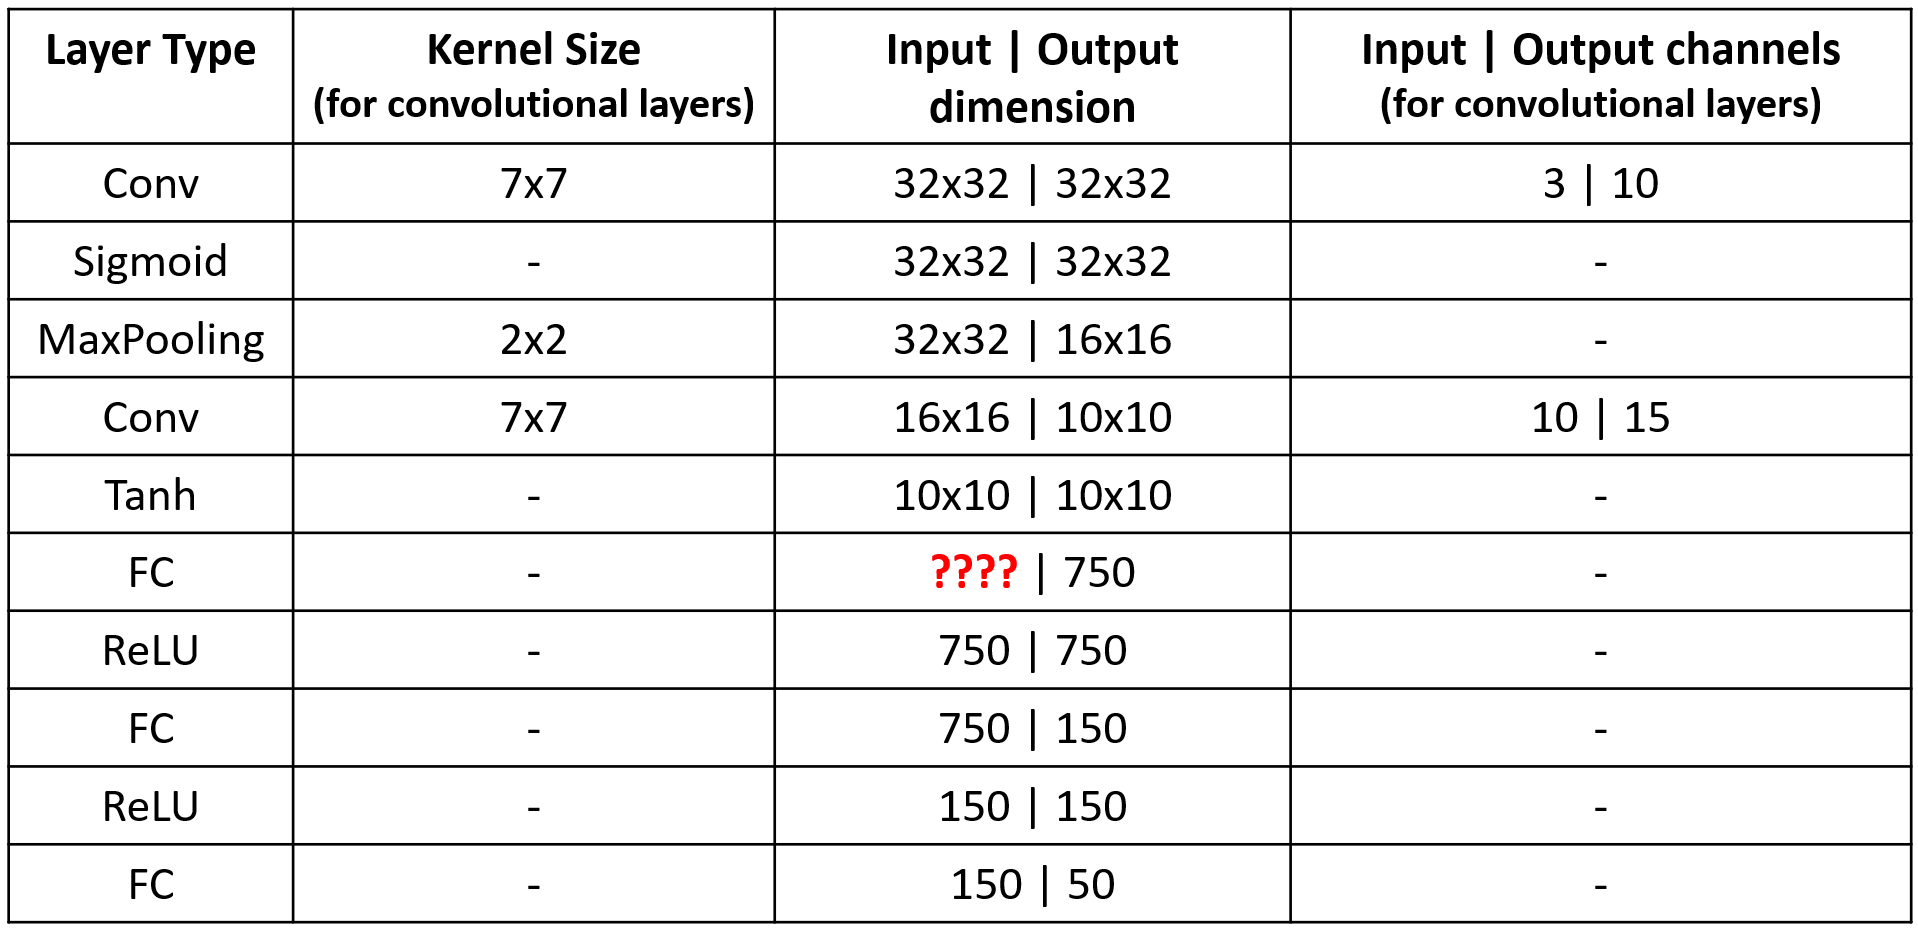

<font color='blue'>Nótese que el tamaño de entrada a la primera FC layer se marca con interrogantes. Esto se debe a que es el alumnado el que debe calcular el valor correspondiente y explicar el cálculo realizado.

<font color='blue'>Los alumnos deben:
1. Crear el código para el modelo *BaseNet* empleando fastai/PyTorch.
2. Explicar y describir cada una de las capas de la arquitectura *BaseNet*, así como las decisiones de implementación tomadas. Por ejemplo:
    - <font color='blue'>¿Qué función de pérdida se debería emplear: `CrossEntropyLoss()`, `CrossEntropyLossFlat()` o alguna otra?
    - ¿Se debería incorporar manualmente, en la definición de la red, la función de activación de la capa final (`nn.Softmax()`)? ¿Por qué?
    - ¿Cómo se ha calculado la dimensionalidad de entrada de la primera FC layer?
3. Desglosar detalladamente el número de parámetros de esta arquitectura, y cuánto contribuye cada capa a dicho número total. Se debe hacer un `summary()` del modelo para verificar que la arquitectura se ha construido adecuadamente y que el número de parámetros es correcto (es decir, se corresponde con lo calculado previamente).
4. Entrenar el modelo, sin aplicar la política de 1 ciclo de Leslie N. Smith, con _SGD_ (`lr=0.01`, `momentum=0.9`), e incluyendo _early stopping_ monitorizando la _loss_ en validación con una paciencia de $5$ durante $25$ épocas, y *batch size* de $128$ ejemplos. A continuación, se debe evaluar el rendimiento por medio de emplear/mostrar/analizar:
    - <font color='blue'>la matriz de confusión en entrenamiento, validación y test;
    - la _accuracy_ en entrenamiento, validación y test;
    - y la evolución, por épocas, tanto de la función de pérdida (en entrenamiento y validación) como de la _accuracy_ (en validación) y el _F1 score (Macro)_ (en validación).



In [ ]:
# We get the CIFAR100 dataset
path = untar_data(URLs.CIFAR_100,force_download=True)

In [ ]:
# The CIFAR_100 dataset, as well as the MNIST dataset, follows a common layout for machine learning datasets:
# separate folders for the training set and the validation set (and/or test set).
# Let's see what's inside both the training and test sets
print(path)
print(path.ls())
print((path/'train').ls())
print((path/'test').ls())
# train_classes = (path/'train').ls()
# test_classes = (path/'test').ls()
train_classes = sorted((path/'train').ls(), key=lambda p: p.name.casefold())
test_classes  = sorted((path/'test').ls(),  key=lambda p: p.name.casefold())
print([p.name for p in train_classes])  # <-- sorted names
print([p.name for p in test_classes])   # <-- sorted names
print(len(train_classes))

/root/.fastai/data/cifar100
[Path('/root/.fastai/data/cifar100/test'), Path('/root/.fastai/data/cifar100/train')]
[Path('/root/.fastai/data/cifar100/train/fish'), Path('/root/.fastai/data/cifar100/train/flowers'), Path('/root/.fastai/data/cifar100/train/household_electrical_devices'), Path('/root/.fastai/data/cifar100/train/large_man-made_outdoor_things'), Path('/root/.fastai/data/cifar100/train/trees'), Path('/root/.fastai/data/cifar100/train/household_furniture'), Path('/root/.fastai/data/cifar100/train/people'), Path('/root/.fastai/data/cifar100/train/non-insect_invertebrates'), Path('/root/.fastai/data/cifar100/train/reptiles'), Path('/root/.fastai/data/cifar100/train/insects'), Path('/root/.fastai/data/cifar100/train/large_omnivores_and_herbivores'), Path('/root/.fastai/data/cifar100/train/large_natural_outdoor_scenes'), Path('/root/.fastai/data/cifar100/train/food_containers'), Path('/root/.fastai/data/cifar100/train/aquatic_mammals'), Path('/root/.fastai/data/cifar100/train/frui

Vemos que hay 20 clases, pero eso no debe confundirnos. Eso son solo las 20 superclases en que está subdividido el dataset. Véase https://github.com/fastai/dlcert2/blob/master/docs/datasets.md:
*"This dataset is just like the CIFAR-10, except it has 100 classes containing 600 images each. There are 500 training images and 100 testing images per class. **The 100 classes in the CIFAR-100 are grouped into 20 superclasses**. Each image comes with a "fine" label (the class to which it belongs) and a "coarse" label (the superclass to which it belongs)."*

In [ ]:
# Queremos verificar que dentro de cada una de las 20 superclases hay 5 clases,
# lo que da las 100 clases que hay. También queremos verificar que el número de imágenes
# es correcto
print('Clases dentro de la primera superclase (',train_classes[0],'): ', train_classes[0].ls())
for i in range(20):
  print('Número de clases dentro de superclase ',i,': ', len(train_classes[i].ls()))
files_train = get_image_files(path/'train')
files_test = get_image_files(path/'test')
print('Total training images: ', len(files_train))
print('Total test images: ', len(files_test))

Clases dentro de la primera superclase ( /root/.fastai/data/cifar100/train/aquatic_mammals ):  [Path('/root/.fastai/data/cifar100/train/aquatic_mammals/dolphin'), Path('/root/.fastai/data/cifar100/train/aquatic_mammals/otter'), Path('/root/.fastai/data/cifar100/train/aquatic_mammals/seal'), Path('/root/.fastai/data/cifar100/train/aquatic_mammals/beaver'), Path('/root/.fastai/data/cifar100/train/aquatic_mammals/whale')]
Número de clases dentro de superclase  0 :  5
Número de clases dentro de superclase  1 :  5
Número de clases dentro de superclase  2 :  5
Número de clases dentro de superclase  3 :  5
Número de clases dentro de superclase  4 :  5
Número de clases dentro de superclase  5 :  5
Número de clases dentro de superclase  6 :  5
Número de clases dentro de superclase  7 :  5
Número de clases dentro de superclase  8 :  5
Número de clases dentro de superclase  9 :  5
Número de clases dentro de superclase  10 :  5
Número de clases dentro de superclase  11 :  5
Número de clases dentro

Ahora nos quedamos con $50$ clases / $10$ superclases (para evitar que no siempre se escojan las mismas, las fijamos manualmente al comienzo de la siguiente celda).

In [ ]:
import shutil
keep_names = {'aquatic_mammals', 'fish', 'flowers', 'fruit_and_vegetables',
              'insects', 'large_carnivores',  'large_omnivores_and_herbivores',
              'reptiles', 'vehicles_1', 'vehicles_2'}
train_classes = sorted((path/'train').ls(), key=lambda p: p.name.casefold())
test_classes  = sorted((path/'test').ls(),  key=lambda p: p.name.casefold())

print('SUPERCLASES ELIMINADAS:')
print('Training Set: ')
for p in train_classes:
    if p.name not in keep_names:
        print(p)
        shutil.rmtree(p)
print('Test Set: ')
for p in test_classes:
    if p.name not in keep_names:
        print(p)
        shutil.rmtree(p)

print('SUPERCLASES CONSERVADAS:')
print('Training Set: ')
for p in train_classes:
    if p.name in keep_names:
        print(p)
print('Test Set: ')
for p in test_classes:
    if p.name in keep_names:
        print(p)


SUPERCLASES ELIMINADAS:
Training Set: 
/root/.fastai/data/cifar100/train/food_containers
/root/.fastai/data/cifar100/train/household_electrical_devices
/root/.fastai/data/cifar100/train/household_furniture
/root/.fastai/data/cifar100/train/large_man-made_outdoor_things
/root/.fastai/data/cifar100/train/large_natural_outdoor_scenes
/root/.fastai/data/cifar100/train/medium_mammals
/root/.fastai/data/cifar100/train/non-insect_invertebrates
/root/.fastai/data/cifar100/train/people
/root/.fastai/data/cifar100/train/small_mammals
/root/.fastai/data/cifar100/train/trees
Test Set: 
/root/.fastai/data/cifar100/test/food_containers
/root/.fastai/data/cifar100/test/household_electrical_devices
/root/.fastai/data/cifar100/test/household_furniture
/root/.fastai/data/cifar100/test/large_man-made_outdoor_things
/root/.fastai/data/cifar100/test/large_natural_outdoor_scenes
/root/.fastai/data/cifar100/test/medium_mammals
/root/.fastai/data/cifar100/test/non-insect_invertebrates
/root/.fastai/data/cifar

Ahora intentamos verificar si las hemos eliminado realmente.

In [ ]:
print(path)
train_classes = (path/'train').ls()
test_classes = (path/'test').ls()
print(len(train_classes))
print(len(test_classes))

/root/.fastai/data/cifar100
10
10


Y que el número de ejemplos en training y test es el correcto.

In [ ]:
print('Clases dentro de la primera superclase (',train_classes[0],'): ', train_classes[0].ls())
files_train = get_image_files(path/'train')
files_test = get_image_files(path/'test')
print('Total training images: ', len(files_train))
print('Total test images: ', len(files_test))

Clases dentro de la primera superclase ( /root/.fastai/data/cifar100/train/fish ):  [Path('/root/.fastai/data/cifar100/train/fish/trout'), Path('/root/.fastai/data/cifar100/train/fish/aquarium_fish'), Path('/root/.fastai/data/cifar100/train/fish/shark'), Path('/root/.fastai/data/cifar100/train/fish/ray'), Path('/root/.fastai/data/cifar100/train/fish/flatfish')]
Total training images:  25000
Total test images:  5000


Podemos observar que ahora tenemos el dataset tal y como nos interesa, con $25000$ imágenes de entrenamiento y $5000$ de test.

Ahora vamos a proceder a cargar los datos de entrenamiento. Para ello hacemos uso de DataLoaders y DataBlock.

Numero de ejemplos de entrenamiento (una vez descartados los de validacion): 22500
Numero de ejemplos de validacion: 2500


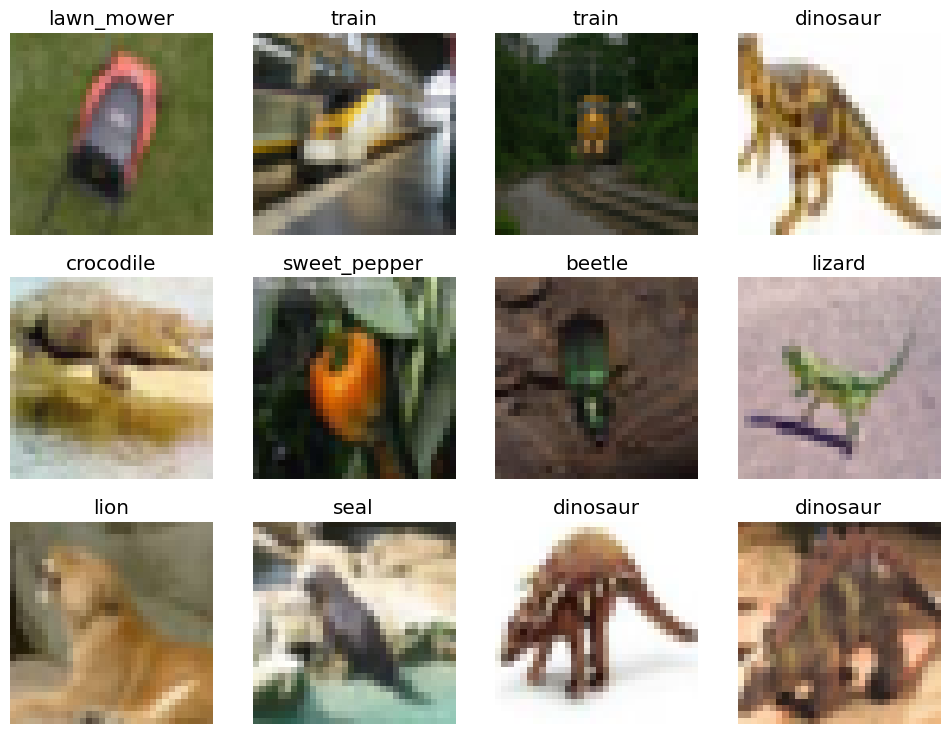

In [ ]:
cifar_mean = (0.5071,0.4865,0.4409)
cifar_std  = (0.2673,0.2564,0.2762)

CIFAR_50 = DataBlock(
    # A CUBRIR POR EL ALUMNADO
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.1, seed=42), #10% of the training set will be used for validation
    get_y=parent_label,
    item_tfms = Resize(32),
    batch_tfms = [IntToFloatTensor(), Normalize.from_stats(cifar_mean, cifar_std)]
    #batch_tfms = [IntToFloatTensor()]
)

dls = CIFAR_50.dataloaders(path/'train',batch_size=128)

dls.show_batch(max_n=12)

print('Numero de ejemplos de entrenamiento (una vez descartados los de validacion):', len(dls.train_ds))
print('Numero de ejemplos de validacion:', len(dls.valid_ds))

Example of training data


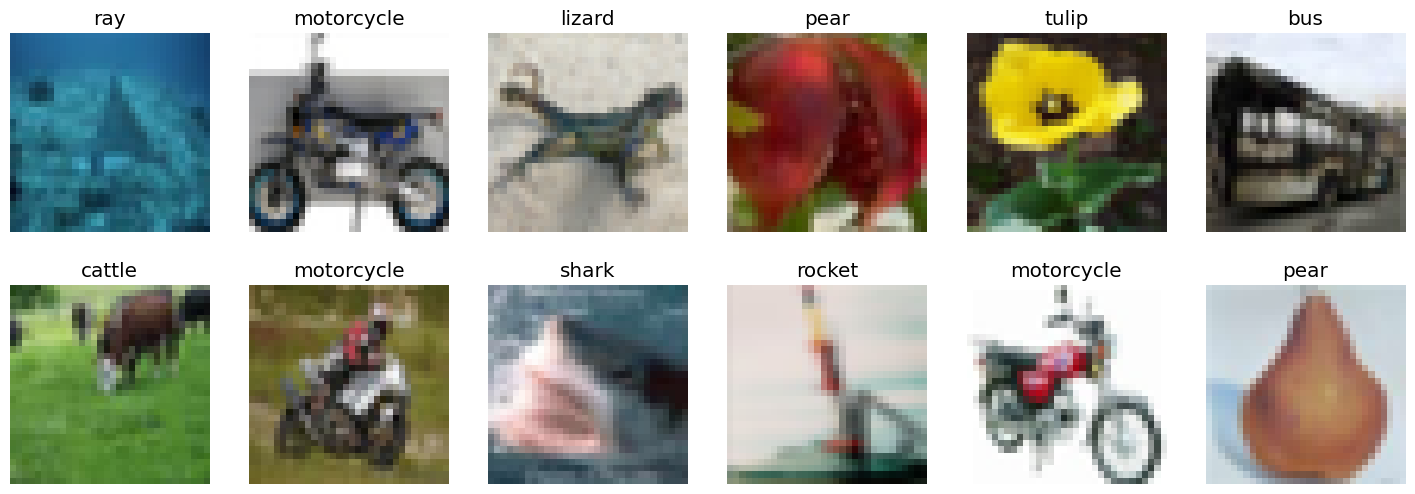

In [ ]:
print('Example of training data')
dls.train.show_batch(max_n=12, nrows=2)

Example of validation data


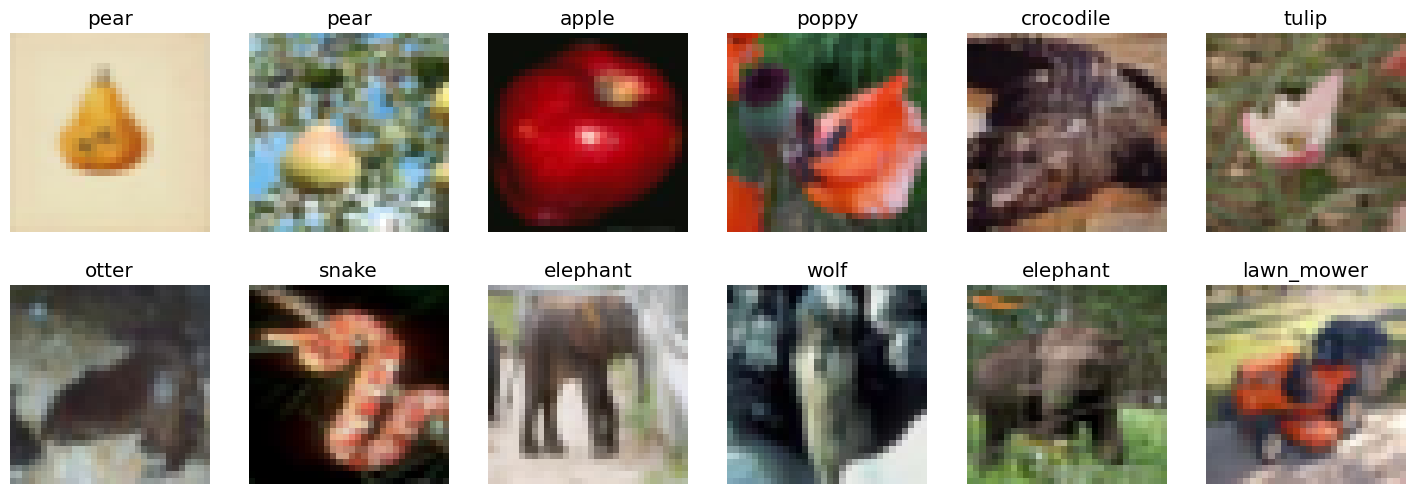

In [ ]:
print('Example of validation data')
dls.valid.show_batch(max_n=12, nrows=2)

Ahora procedemos con la creación de la red BaseNet.

<font color='blue'>Estamos ante un problema multi clase con una sola etiqueta. La arquitectura BaseNet consta de las siguientes capas:

<font color='blue'>1. Capa Convolucional, que aplica una convolución para extraer características como bordes, texturas y objetos desplazando filtros aprendibles(kernels) sobre la entrada. Tiene como parámetros el número de canales de entrada(3 en este caso porque es una imagen RGB), el número canales de salida(10 en esta primera capa), el tamaño del kernel, 7, stride(el paso de desplazamiento del kernel, 1 en este caso) el padding(que es 3 porque aplicando la fórmula vista en clase Output_size = ((N+2*P-F)/stride) +1 sabiendo que Output_size = 32, N=32, F=7 y stride=1 despejamos y obtenemos P=3), y por último el bias, que es un parámetro que se aplica a la salida de la convolución, similar al término bias en una función linear $f(x) = wx + b$, y por defecto se pone a True.

<font color='blue'>2. Sigmoide, una función de activación que introduce no-linealidad en redes neuronales, permitiendo aprender patrones complejos de los datos. Como no la estamos aplicando a la salida se puede usar sin problema, aunque hoy en día ReLU es mas común(recordemos que si se aplicase a la capa de salida tendríamos que usar Softmax, que fuerza que las probabilidades de todas las clases sumen 1).

<font color='blue'>3. MaxPool2d, es una técnica de submuestreo usado en redes neuronales convulacionales para reducir las dimensiones de la entrada conservando las caracteristicas mas importantes. Divide la entrada en regiones de pooling rectangulares y calcula el máximo de cada región. Normalmente MaxPool se usa después de una capa convulacional para reducir el sobreajuste y mejorar la generalización del modelo. El valor 2 indica que usa un kernel 2x2, resultando en una reducción del tamaño de las imágenes a 16x16.

<font color='blue'>4. Otra capa Convolucional, en este caso con 10 canales de entrada, que coinciden con los de salida de la anterior capa y 15 canales de salida. En este caso también hay reducción del tamaño de las imágenes ya que no se aplica padding de 16x16 a 10x10, $(16-7)/1 + 1 = 10$.

<font color='blue'>5. Tanh, aplica la función de activación tangente hiperbólica, se usa también para introducir no-linealidad, para que el modelo aprenda patrones complejos.
\begin{equation}
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
\end{equation}
Esta función mapea los valores de entrada al rango
$(-1,1)$, lo que la hace centrada en cero, ayudando en el entrenamiento de redes neuronales profundas al mejorar el flujo del gradiente en comparación con la función sigmoide.
El tensor de salida tiene la misma forma y tipo de datos que el tensor de entrada.

<font color='blue'>6. Flatten, se utiliza para reformar tensores de entrada en una sola dimensión, y se aplica comúnmente al final de un modelo de red neuronal antes de las fully connected layers.

<font color='blue'>7. Linear(1500, 750), crea una capa lineal con un número especificado de características de entrada y salida, y opcionalmente aplica una función de activación e inicializa los pesos utilizando un método determinado.
Declaración: Linear(in_features, out_features, bias=True, act_cls=None, init='auto').
En este caso, Linear(1500, 750) crea una capa lineal que mapea 1500 características de entrada a 750 características de salida, incluyendo un término de sesgo (bias) y sin aplicar una función de activación. **La dimensionalidad de entrada de la primera FC layer se obtiene de la siguiente manera, Tanh tiene un output dimension de $10x10x15$, al aplicar flatten antes de FC, tenemos que el número de características de entrada = $10*10*15 = 1500$.**

<font color='blue'>8. Relu, es un componente fundamental en los modelos de aprendizaje profundo, ya que también proporciona no linealidad, lo que permite a los modelos aprender patrones complejos.
Su funcionamiento consiste en establecer en cero todos los valores negativos del tensor de entrada, permitiendo que solo los valores positivos pasen a la siguiente capa.
También es importante en el teorema de aproximación universal visto en clase, el cual establece que una red neuronal con suficientes parámetros puede aproximar cualquier función continua, siempre que incluya funciones de activación no lineales, como ReLU.

<font color='blue'>9. Linear(750, 150), creamos otra capa lineal que mapea 750 características de entrada(el número de características obtenido en la anterior capa) a 150 características de salida.
    
<font color='blue'>10. ReLU(), entre medias de ambas capas usamos Relu de nuevo.

<font color='blue'>11. Linear(150, 50), creamos un última capa lineal que mapea 150 características de entrada(el número de características obtenido en la anterior capa) a 50 características de salida.

<font color='blue'>En resumen, aprende un mapeo de una imagen $32x32x3$ a una de $50$ clases, que es el subconjunto que habíamos cogido del dataset.

<font color='blue'>Los dos bloques convolucionales aprenden rasgos primero de bajo nivel y luego más complejos, las fully connected layers toman el vector de 1500 características y produce 50 valores de salida, uno por clase.

<font color='blue'>En el entrenamiento, CrossEntropy convierte esas salidad en una distribución y hace que el modelo asigne una probabilidad alta a la clase correcta.

<font color='blue'>**Respecto a la función de pérdida empleada, CrossEntropyLossFlat es un envoltorio (wrapper) de la función nn.CrossEntropyLoss de PyTorch que aplana automáticamente tanto los tensores de entrada como los de destino antes de calcular la pérdida (loss).
Esto resulta especialmente útil en tareas como la segmentación de imágenes, donde las dimensiones de entrada y destino pueden no coincidir directamente con las que espera la función de entropía cruzada estándar.
Además, la clase CrossEntropyLossFlat hereda de BaseLoss, que ofrece una función de activación asociada (softmax).
En contraste, la función nn.CrossEntropyLoss de PyTorch no realiza el aplanamiento y puede generar un error de forma (shape error) si los tensores de entrada y destino tienen formas no coincidentes, como ocurre con tensores 4D en modelos de segmentación.
Por ello, fastai recomienda usar CrossEntropyLossFlat en lugar de nn.CrossEntropyLoss para evitar errores de dimensiones y simplificar el flujo de entrenamiento.**

<font color='blue'>**Es por ello que no usamos Softmax al final, ya que sería volver a aplicar lo mismo(CrossEntropyLossFlat internamente aplica softmax como parte de sus cálculos) luego ya no es necesario aplicarlo al final ya que además puede hacer que el modelo no sea tan bueno.**

In [ ]:
from torch import nn
import torch.nn.functional as F

BaseNet = nn.Sequential(
    # A CUBRIR POR EL ALUMNADO
    nn.Conv2d(3, 10, kernel_size=7, stride=1, padding=3),
    nn.Sigmoid(),
    nn.MaxPool2d(2),
    nn.Conv2d(10, 15, kernel_size=7, stride=1, padding=0),
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(1500, 750),
    nn.ReLU(),
    nn.Linear(750, 150),
    nn.ReLU(),
    nn.Linear(150, 50)
)

BaseNet

Sequential(
  (0): Conv2d(3, 10, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (1): Sigmoid()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(10, 15, kernel_size=(7, 7), stride=(1, 1))
  (4): Tanh()
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=1500, out_features=750, bias=True)
  (7): ReLU()
  (8): Linear(in_features=750, out_features=150, bias=True)
  (9): ReLU()
  (10): Linear(in_features=150, out_features=50, bias=True)
)

<font color='blue'>Ahora vamos a crear el Learner, que es el objeto que define el proceso de aprendizaje. Incluye información importante como:

- <font color='blue'>modelo: BaseNet
- uso de parámetro preentrenados: no hay
- función de pérdida: CrossEntropyLossFlat(), se usa para calcular la pérdida de entropía cruzada en tareas como clasificación, manejando automáticamente tensores con varias dimensiones (como imágenes). Lo que hace es aplanar la predicción y el objetivo para convertirlos en vectores compatibles y luego aplica la CrossEntropyLoss estándar de PyTorch.
- metrics: Accuracy, F1Score, la primera mide el porcentaje de predicciones correctas sobre el total de muestras.
Indica qué tan a menudo el modelo acierta, pero puede ser engañosa si las clases están desbalanceadas.
y la segunda mide el balance entre precisión y recall, combinándolos en una sola métrica armónica.
Es útil cuando las clases están desbalanceadas, porque evalúa tanto falsos positivos como falsos negativos.
- learning rate: El tamaño de paso en el algoritmo del gradiente descendente
- dls: El objeto sata loader que da los conjuntos de datos de entrenamiento y validacion al modelo
- cbs: Lista de callbacks para customizar el bucle de aprendizaje, nosotros hemos añadido EarlyStoppingCallBack, que si durante un numero mayor del indicado en patience no mejora en valid_loss en este caso, toma el ultimo mejor valor y detiene la ejecución.
- opt_func: La función de optimización, determina el algoritmo para actualizar los pesos del modelo basado en las computaciones del gradiente, en nuestro caso, SGD(Stochastic Gradient Descent), que actualiza los parámetros usando solo un ejemplo de entrenamiento cada vez, lo que lo hace rápido y adecuado para datasets grandes, pero a la vez el camino a la convergencia puede ser ruidoso.

<font color='blue'>También me gustaría hablar de como funciona el algoritmo de gradiente descendente.

<font color='blue'>El gradiente descendente es un algoritmo de optimización que ajusta iterativamente los parámetros de un modelo para minimizar una función de pérdida, moviéndose en cada paso en la dirección en la que esa pérdida disminuye más rápido.

<font color='blue'>El problema que intenta resolver es el de encontrar los parámetros θ que minimizan una función de coste o pérdida L(θ), que mide el error entre los valores predichos y los actuales.

<font color='blue'>El gradiente ∇_θ L(θ) es el vector de derivadas parciales de L respecto a cada parámetro: ∇_θ L(θ) = (∂L/∂θ₁, ∂L/∂θ₂, …). Nos dice, para cada parámetro del modelo, si aumentar ese parámetro hace que la pérdida suba o baje y con qué intensidad.

<font color='blue'>Lo importante es que el gradiente apunta en la dirección en la que la función L(θ) crece más rápido. Por eso, si lo que queremos es reducir la pérdida, lo que tenemos que hacer es movernos en la dirección contraria al gradiente, es decir, en dirección −∇θ L(θ).

<font color='blue'>La regla de actualización del gradiente descendente es: θ(t+1) = θ_t - η · ∇_θ L(θ_t), donde η es el learning rate. En cada iteración calculamos el gradiente, restamos una pequeña fracción de ese gradiente a los parámetros y repetimos muchas veces.

<font color='blue'>En el caso de redes neuronales, θ incluye todos los pesos y biases de todas las capas. La idea como sabemos es primero hacer un forward pass para obtener las predicciones y calcular la pérdida L(θ), luego usar backpropagation para obtener el gradiente ∇_θ L(θ). Luego con la fórmula iterativa actualizamos los parámetros. Este proceso se repite durante muchas épocas sobre los datos de entrenamiento.

In [ ]:
opt_func = partial(SGD, mom=0.9)
#opt_func = Adam

learn = Learner(
    dls=dls,
    model=BaseNet,
    loss_func=CrossEntropyLossFlat(),
    opt_func=opt_func,
    cbs=[
        EarlyStoppingCallback(monitor='valid_loss', patience=5),
    ],
    metrics=[accuracy, F1Score(average='macro')],
)


<font color='blue'>Para calcular el número de parámetros de esta arquitectura hay que sumar los parámetros de cada capa, para ello se coge el tamaño del kernel k, el número de canales de la entrada in y el de la salida out, y aplicamos:

<font color='blue'>parámetros por filtro = $k*k*in + 1$

<font color='blue'>total parámetros de la capa = parámetros por filtro $*$ out

<font color='blue'>*Para la capa 1:*

<font color='blue'>parámetros por filtro = $k*k*in + 1 = 7*7*3 + 1 = 148$

<font color='blue'>total parámetros de la capa = $148*10 = 1480$

<font color='blue'>*Para la capa 2:*

<font color='blue'>parámetros por filtro = $k*k*in + 1 = 7*7*10 + 1 = 491$

<font color='blue'>total parámetros de la capa = $491*15 = 7365$

<font color='blue'>Para una fully connected layer, el número total de parámetros entrenables, incluyendo los términos de sesgo (bias), se calcula como el producto del número de unidades de entrada por el número de unidades de salida, más el número de unidades de salida (que corresponden a los sesgos).

<font color='blue'>\begin{equation}
\text{Parámetros} = (\text{unidades de entrada} \times \text{unidades de salida}) + \text{unidades de salida}
\end{equation}

<font color='blue'>*Para la FC1:*

<font color='blue'>$Parámetros = 1500*750 + 750 = 1.125.750$

<font color='blue'>*Para la FC2:*

<font color='blue'>$Parámetros = 750*150 + 150 = 112.650$

<font color='blue'>*Para la FC3:*

<font color='blue'>$Parámetros = 150*50 + 50 = 7550$

<font color='blue'>**Sumando todos los parámetros nos queda: $1.254.795$**

In [ ]:
learn.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 10 x 32 x 32  
Conv2d                                    1480       True      
Sigmoid                                                        
____________________________________________________________________________
                     128 x 10 x 16 x 16  
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 15 x 10 x 10  
Conv2d                                    7365       True      
Tanh                                                           
____________________________________________________________________________
                     128 x 1500          
Flatten                                                        
____________________________________________________________________________
                     128 x 750  

In [ ]:

learn.fit(25, lr=0.01)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.819377,3.653680,0.061600,0.021838,00:30
1,3.328151,3.221830,0.151600,0.110202,00:20
2,3.143200,3.070379,0.183600,0.138938,00:21
3,2.976442,2.955067,0.213600,0.193037,00:20
4,2.869380,2.866198,0.229600,0.205555,00:22
5,2.791201,2.756670,0.257600,0.236535,00:21
6,2.697219,2.682318,0.287600,0.271932,00:21
7,2.614039,2.657227,0.287200,0.268487,00:20
8,2.558239,2.615185,0.291200,0.277009,00:21
9,2.470939,2.566443,0.316400,0.294547,00:20


No improvement since epoch 16: early stopping


In [ ]:
print(learn.recorder.metric_names)
import numpy as np
print(np.array(learn.recorder.values).shape)


['epoch', 'train_loss', 'valid_loss', 'accuracy', 'f1_score', 'time']
(22, 4)


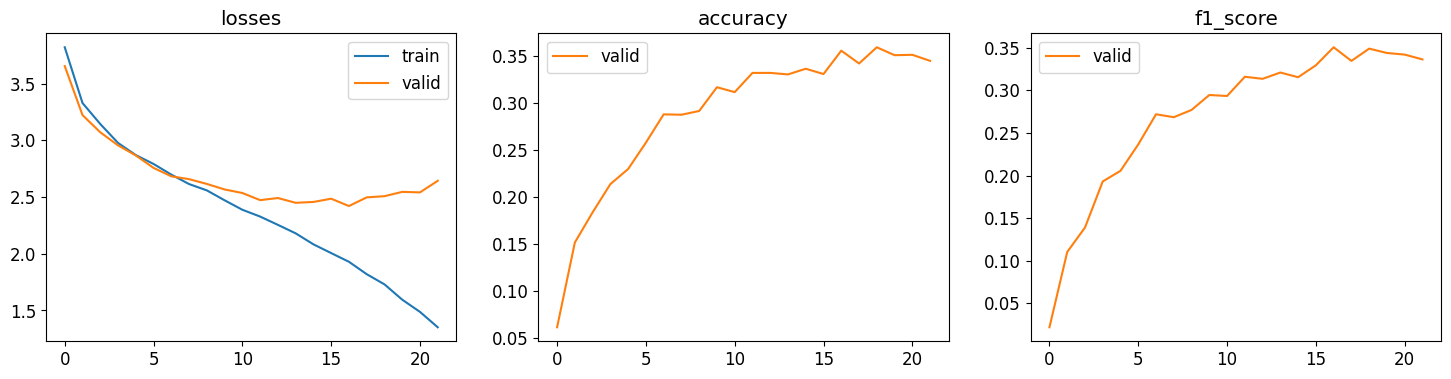

In [ ]:
learn.recorder.plot_metrics()

Train  - loss 1.0920  acc 0.6855  F1 0.6812
Valid  - loss 2.6430  acc 0.3444  F1 0.3363
Test   - loss 2.5650  acc 0.3616  F1 0.3545


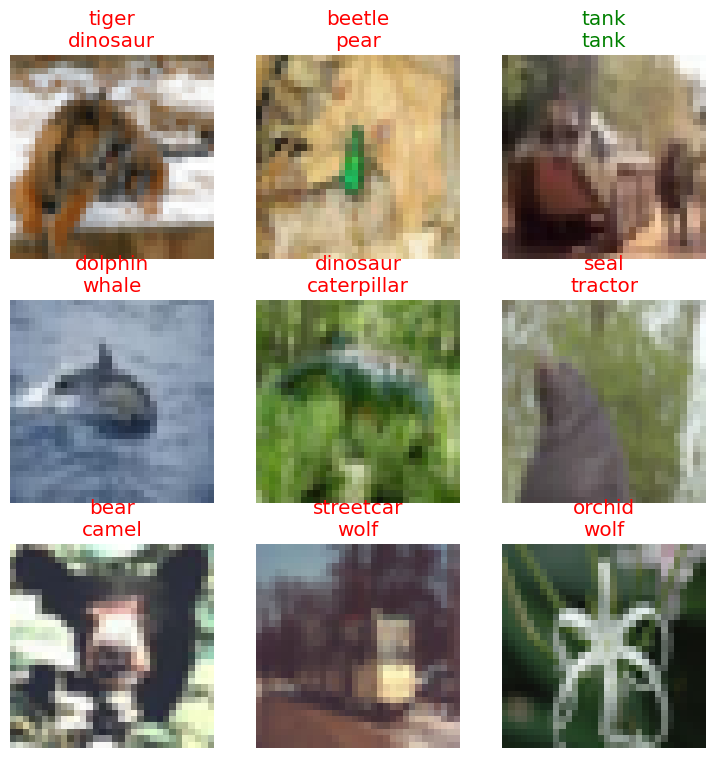

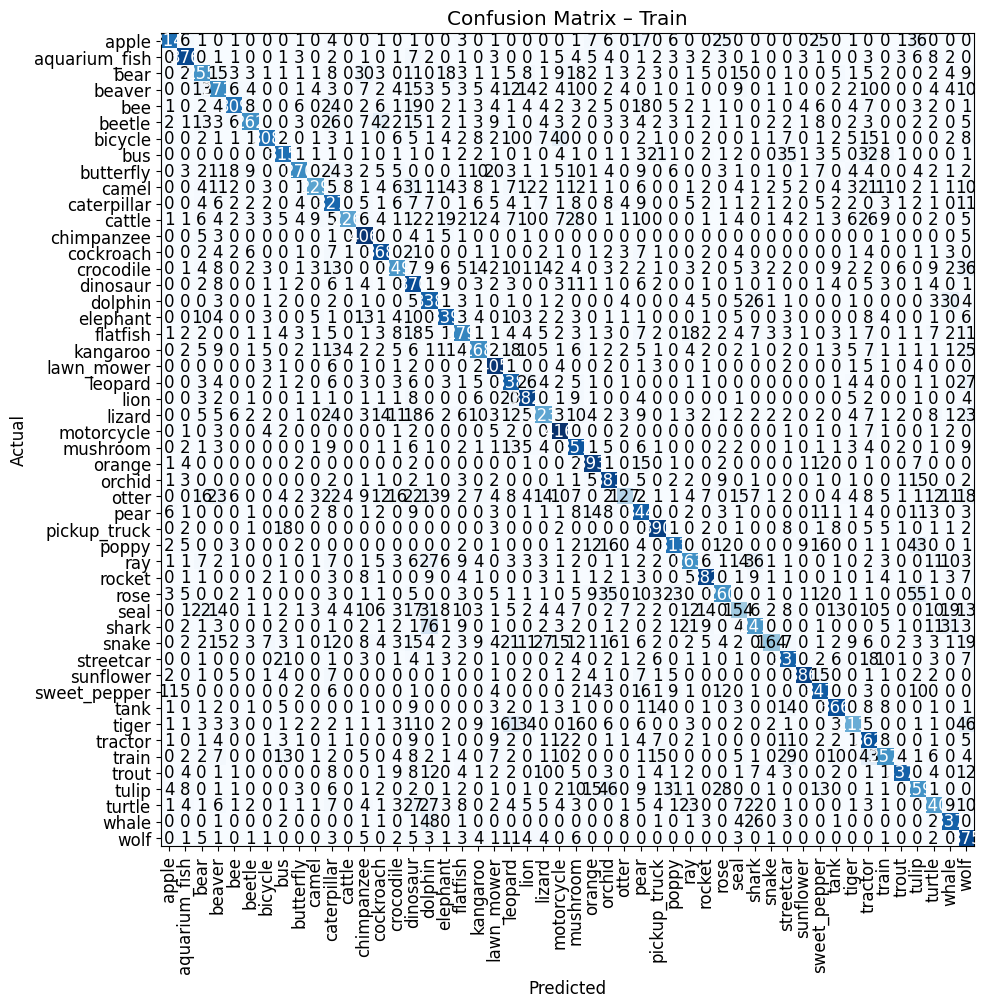

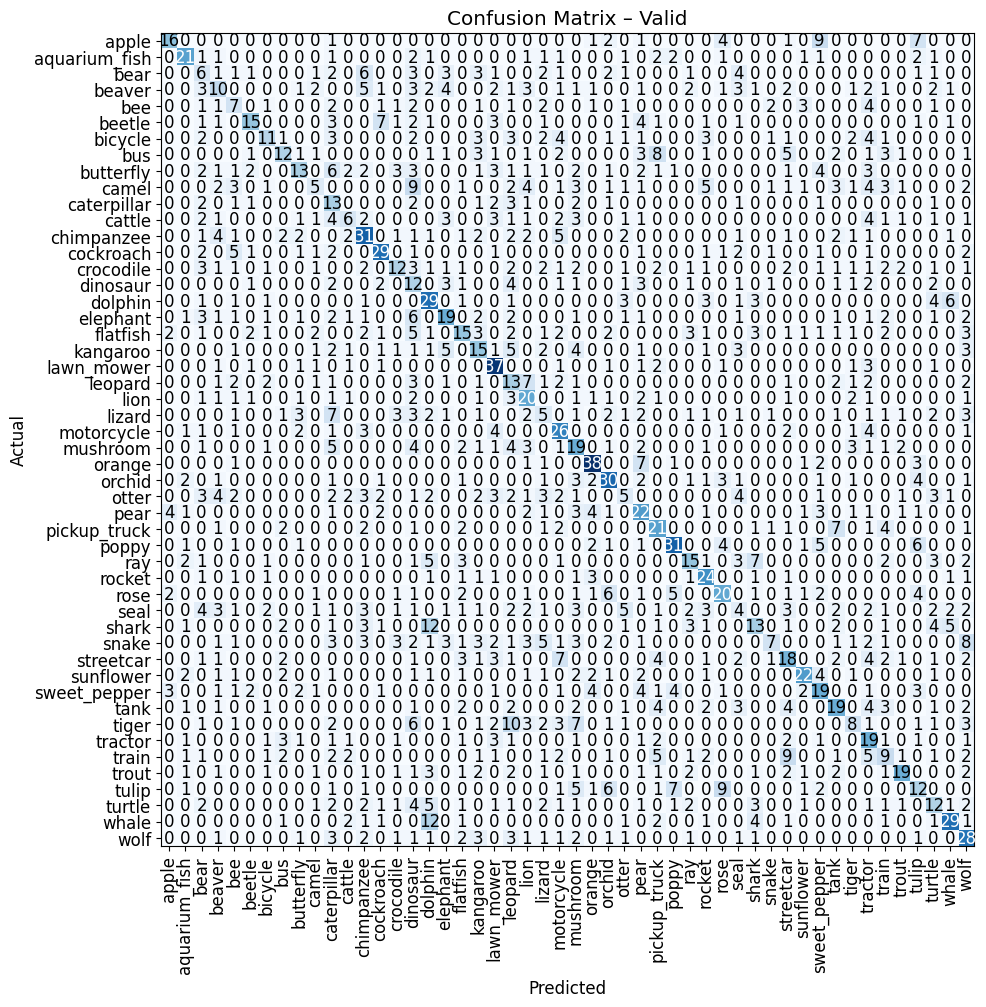

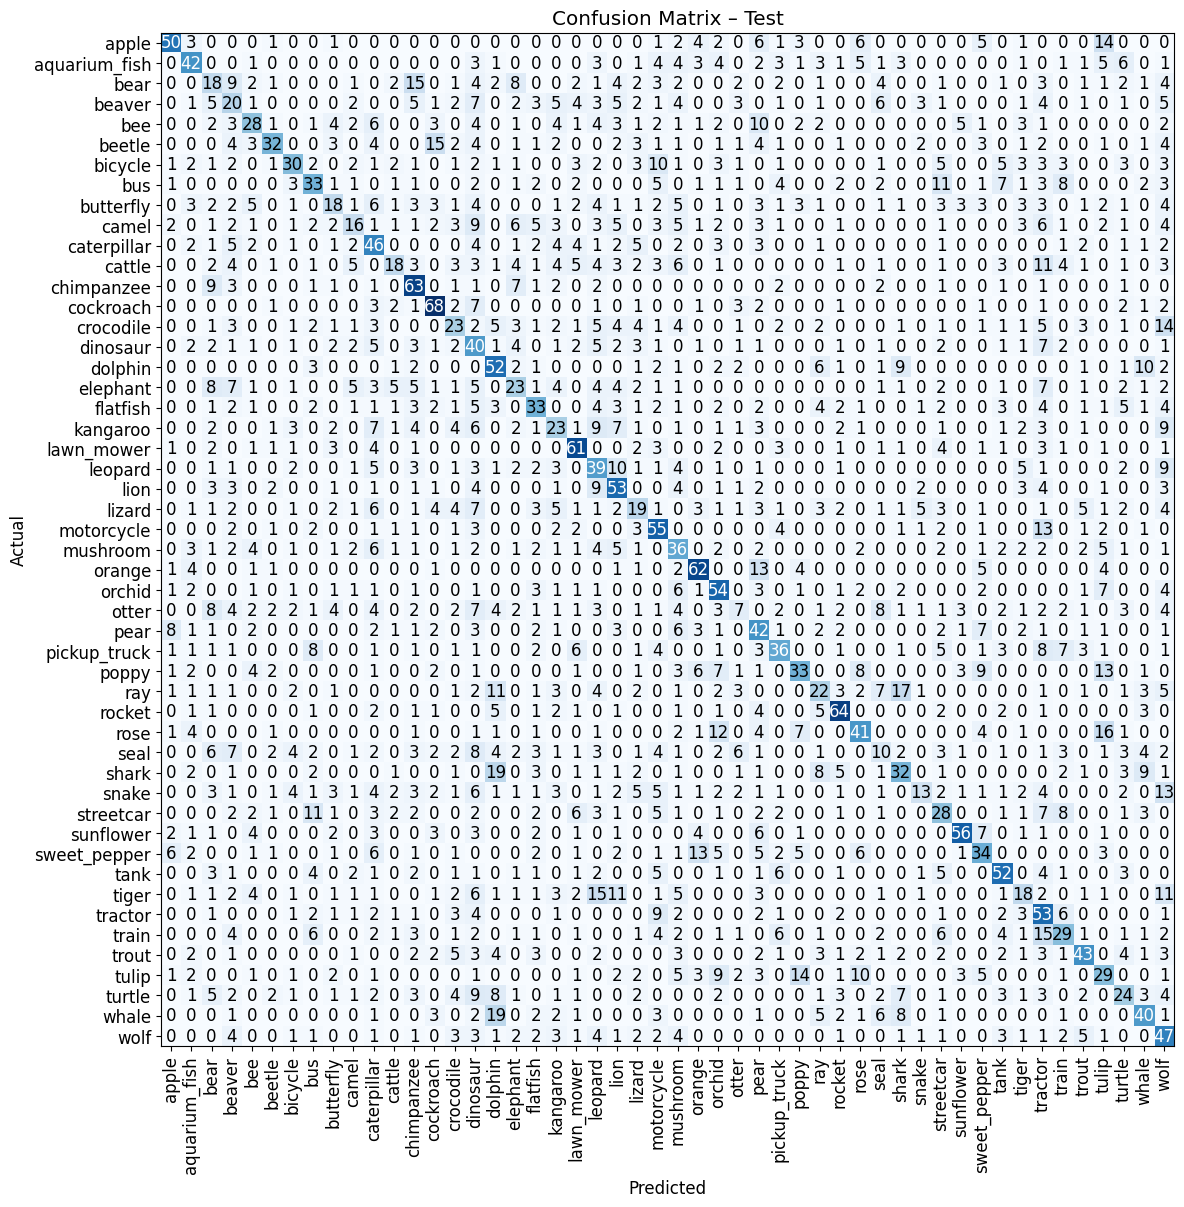

In [ ]:
# A CUBRIR POR EL ALUMNADO
learn.show_results()

test_dl = dls.test_dl(get_image_files(path/'test'), with_labels=True)
loss_tr, acc_tr, f1_tr = learn.validate(dl=dls.train)
loss_va, acc_va, f1_va = learn.validate(dl=dls.valid)
loss_te, acc_te, f1_te = learn.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  acc {acc_tr:.4f}  F1 {f1_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  acc {acc_va:.4f}  F1 {f1_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  acc {acc_te:.4f}  F1 {f1_te:.4f}")

# We compute the confusion matrix
from fastai.interpret import ClassificationInterpretation
interp_tr = ClassificationInterpretation.from_learner(learn, dl=dls.train)
interp_tr.plot_confusion_matrix(figsize=(10,10), title='Confusion Matrix – Train')

interp_va = ClassificationInterpretation.from_learner(learn, dl=dls.valid)
interp_va.plot_confusion_matrix(figsize=(10,10), title='Confusion Matrix – Valid')

interp_te = ClassificationInterpretation.from_learner(learn, dl=test_dl)
interp_te.plot_confusion_matrix(figsize=(12,12), title='Confusion Matrix – Test')

<font color='blue'>**Evaluación del rendimiento**


<font color='blue'>Podemos ver en test y validación obtiene resultados similares, aproximadamente accuracy de en test 0.361 y de 0.344 en validación y F1 de en test 0.354 y de 0.336 en validación. Son resultados que no son muy buenos, ya que está acertando algo más del 30% de las veces, es decir casi dos de cada tres veces se equivoca.

<font color='blue'>Por otro lado la métrica F1 Score mide tanto la precisión (cuántas de las predicciones positivas realizadas por el modelo fueron correctas, respondiendo a la pregunta: "De todas las predicciones positivas, ¿cuántas eran verdaderamente positivas?") como la recuperación (cuántos de los casos positivos reales fueron correctamente identificados por el modelo, respondiendo a: "De todos los casos positivos reales, ¿cuántos detectó el modelo?").
La fórmula para calcular la puntuación F1 es:

<font color='blue'>\begin{equation}
F1 = 2*\frac{Precision*Recuperacion}{Precision+Recuperacion}
\end{equation}

<font color='blue'>Esta fórmula garantiza que la puntuación F1 alcance su valor máximo de 1 solo cuando tanto la precisión como la recuperación son perfectas, y su valor mínimo de 0 cuando alguna de las dos métricas es cero.

<font color='blue'>En el contexto de la visión artificial, esta métrica es especialmente útil porque equilibra la necesidad de detectar todos los objetos reales (alta recuperación) sin generar demasiadas falsas alarmas (alta precisión).

<font color='blue'><font color='blue'>Vemos que los resultados de la métrica F1 también son bastante mejorables. Por otro lado, otro aspecto a comentar es que el modelo sobreajusta ligeramente, ya que podemos observar que en entrenamiento el accuracy sube a 0.6855 y F1 a 0.6812.

<font color='blue'>Por otro lado analizando la evolución de las métricas durante las distintas época, podemos observar que inicialmente el modelo es prácticamente aleatorio pero conforme van avanzando las época el modelo e va actualizando y va aprendiendo cada vez mejor.

<font color='blue'>Un detalle que podemos apreciar en las matrices de confusión es que confunde muchas imagenes similares, lo que tiene sentido, por ejemplo, confunde imágenes de tigre con las de leopardo y leon, las de rosas con las de tulipanes o las de ballenas y tiburones con las de delfines.

<font color='blue'>*Anexo:* Estos son los resultados con un learning rate y un momentum muy bajo(lr=0.0001, momentum=0.1). Viendo los resultados vemos que Accuracy en test está aproximádamente en el $2%$ y F1 en $0.001$, por lo que podemos decir que  tiene un rendimiento práctixamente aleatorio, de hecho una predicción uniforme, ya que tenemos 50 clases y $\frac{1}{50} = 0.02$. Viendo las Confusion Matrix, vemos que predice casi siempre la misma clase, evidentemente sin acierto en la gran mayoría de los casos. Como conclusión se puede decir que con SGD y los parámetros(lr=1e-4, mom=0.1)usados, además de con las funciones de activación Sigmoide y Tanh y usando 25 época no consigue mejorar, algo que también vemos en la no mejora de las métricas durante las distintas épocas.

<font color='blue'>En conclusión podemos decir que con un learning rate tan bajo sencillamente el modelo no es capaz de aprender.

##  Comparando GPU y CPU (0.5 puntos)

Ahora el alumnado debe entrenar el mismo modelo, pero con CPU (`Entorno de Ejecución - Cambiar tipo de entorno de ejecución - CPU`). ¿Qué ocurre? ¿Hay alguna diferencia en cuanto al entrenamiento? ¿Qué ocurre si empleamos un batch size de tamaño $1$ o $256$ en CPU o GPU?

**Nota1**: no hay forma programática de ir cambiando de entorno de ejecución dentro de un bucle. De modo que es necesario modificarlo manualmente en `Entorno de ejecución`.

**Nota2**: no se trata de realizar un estudio exhaustivo ni de repetir el ejercicio al completo con distintos entornos de ejecución (CPU, GPU A100, GPU L4, GPU T4, TPU v6e-1, TPU v5e-1), aunque, quien quiera, es libre de hacerlo. Se trata solamente de documentar algunos breves experimentos (por ejemplo, empleando menos épocas), e intentar explicar los resultados obtenidos a nivel de tiempos de entrenamiento, y cómo en dichos tiempos influye el tamaño del batch y el entorno hardware en que se entrena.

<font color='blue'>Primero me gustaría comentar que un batch es un conjunto de datos procesados en una iteración tras la cual hay actualización de pesos, y una época es un ciclo entero sobre el dataset entero. Por ejemplo, para un dataset de 60.000 imágenes y un batch size de 128, aproximádamente hacen falta 469 iteraciones para completar una época. Dicho esto, los resultados obtenidos para cada entorno de ejcución y los distintos batches son los siguientes:

<font color='blue'>**CPU**

<font color='blue'>*Batch size = 1*

<font color='blue'>Train  - loss 3.9392  acc 0.0204  F1 0.0008

<font color='blue'>Valid  - loss 3.9431  acc 0.0168  F1 0.0007

<font color='blue'>Test   - loss 3.9395  acc 0.0200  F1 0.0008

<font color='blue'>Tiempo: 4 horas

<font color='blue'>*Batch size = 128*

<font color='blue'>Train  - loss 1.1347  acc 0.6733  F1 0.6672

<font color='blue'>Valid  - loss 2.7434  acc 0.3356  F1 0.3313

<font color='blue'>Test   - loss 2.6104  acc 0.3468  F1 0.3403

<font color='blue'>Tiempo: 16 minutos

<font color='blue'>*Batch size = 256*

<font color='blue'>Train  - loss 2.0302  acc 0.4308  F1 0.4187

<font color='blue'>Valid  - loss 2.5083  acc 0.3284  F1 0.3165

<font color='blue'>Test   - loss 2.4293  acc 0.3476  F1 0.3375

<font color='blue'>Tiempo: 18 minutos

<font color='blue'>**GPU**

<font color='blue'>*Batch size = 1*

<font color='blue'>Train  - loss 3.9337  acc 0.0199  F1 0.0008

<font color='blue'>Valid  - loss 3.9415  acc 0.0208  F1 0.0008

<font color='blue'>Test   - loss 3.9343  acc 0.0200  F1 0.0008

<font color='blue'>Tiempo: 41 minutos

<font color='blue'>*Batch size = 128*

<font color='blue'>Train  - loss 1.0920  acc 0.6855  F1 0.6812

<font color='blue'>Valid  - loss 2.6430  acc 0.3444  F1 0.3363

<font color='blue'>Test   - loss 2.5650  acc 0.3616  F1 0.3545

<font color='blue'>Tiempo: 7 minutos

<font color='blue'>*Batch size = 256*

<font color='blue'>Train  - loss 2.0693  acc 0.4209  F1 0.4089

<font color='blue'>Valid  - loss 2.4625  acc 0.3288  F1 0.3156

<font color='blue'>Test   - loss 2.4198  acc 0.3396  F1 0.3276

<font color='blue'>Tiempo: 8 minutos

<font color='blue'>Obeservando los resultados podemos ver que con la CPU entrena mucho más lento. Por otro lado con tamaño de Batch de 128 y 256 las métricas son similares a la GPU, en cambio con un tamaño de batch = 1 no solo aumenta el tiempo de entrenamiento enormemente si no que los resultados son prácticamente al azar. Esto se debe a que al aumentar el tamaño del batch la actualización del gradiente tiene en cuenta una parte significativa del conjunto de datos.
Con un Batch menor → entrenamiento con gradientes estimados a partir de una parte menor
del conjunto de datos. Un «fragmento» más pequeño del conjunto de datos será menos representativo de la relación general
entre las características y las etiquetas.
Sin embargo, podemos comprobar también que aumentar el tamaño del Batch disminuye la capacidad para generalizar a conjuntos de datos no vistos → Genaralization Gap.

<font color='blue'>Podemos decir también que el que obtiene mejores resultados es la GPU con un tamaño de batch de 128 tanto en métricas como en tiempo, aunque con ese mismo tamaño de batch las métricas que obtiene la CPU son parecidas, aunque tarda algo más del doble de tiempo. Lo que tiene sentido ya que al ejecutar con la GPU sobre todo lo que mejoras es la reducción del tiempo de entrenamiento.

##  Eliminando FC layers (0.5 puntos)

Sabemos que el hecho de tener FC layers en una red convolucional fuerza a la entrada a tener un determinado tamaño. Del mismo modo, sabemos que las FC layers concentran buena parte de los pesos de una red. ¿De qué modo podríamos eliminarlas de nuestra arquitectura?  En este apartado debe implementar BaseNet pero sin utilizar FC layers. ¿Cuántos pesos tiene el nuevo modelo? Entrene el nuevo modelo siguiendo el mismo protocolo de entrenamiento, con los mismos hiperparámetros, del primer apartado. ¿Qué rendimiento se obtiene ahora? ¿Por qué?

<font color='blue'>Una capa totalmente conectada (FC), también llamada capa densa, es un componente fundamental de las redes neuronales en el que cada neurona de la capa está conectada con todas las neuronas de la capa anterior, creando una red completa de interconexiones. Esto ayuda a la red a capturar relaciones no lineales entre las variables de entrada.

<font color='blue'>Son especialmente eficaces como capas finales en arquitecturas de redes neuronales, donde convierten las características de alto nivel extraídas por capas anteriores en puntuaciones de salida (por ejemplo, probabilidades de clase). En una red neuronal convolucional (CNN), las capas FC suelen ir después de las capas de convolución y pooling para interpretar los mapas de características y realizar la clasificación final. Antes de aplicar una capa FC, la salida previa suele aplanarse en un vector unidimensional que sirve como entrada.

<font color='blue'>También presentan inconvenientes importantes, como alto coste computacional y uso de memoria, que crecen de forma cuadrática con el tamaño de la entrada, lo que las vuelve menos eficientes para entradas grandes. Para mitigar problemas como el sobreajuste, se emplean técnicas como dropout y regularizaciones L1/L2. A pesar de estas limitaciones, las capas FC siguen siendo cruciales cuando se requiere integrar información global de toda la representación de entrada.

<font color='blue'>Para elimiar las Fully Connected layers tendremos que sustituirlas por capas convolucionales. Esta conversión es posible porque una capa totalmente conectada puede reemplazarse matemáticamente por una capa convolucional con un kernel del mismo tamaño que las dimensiones espaciales del mapa de características de entrada.
Por ejemplo, si un mapa de características de tamaño $H*W*C$ se introduce en una capa FC, se puede sustituir por una capa convolucional con $K$ filtros, cada uno de tamaño $H*W*C$, produciendo una salida $1*1*K$.

<font color='blue'>De forma alternativa y más habitual actualmente, se pueden usar convoluciones $1*1$ para reemplazar capas FC reformando la entrada a un formato $N*1*1$, donde $N$ es el número de características, y aplicando una convolución con $K$ filtros de tamaño $1*1$.

<font color='blue'>Eliminar las capas FC también reduce el número de parámetros y evita tener que aplanar mapas de características, lo que puede provocar pérdida de información espacial.

<font color='blue'>Por todo lo anterior lo que vamos a hacer es sustituir las FC por una capa convolucional, en este caso con 15 canales de entrada, que coinciden con los de salida de la anterior capa y 50 canales de salida. En este caso no hay reducción del tamaño de las imágenes, aplicando la fórmula vista en clase Output_size = ((N+2*P-F)/stride) +1 sabiendo que Output_size = 10, N=10, F=1 y stride=1 despejamos y obtenemos padding=0).

<font color='blue'>Con esto pasamos de tener imágenes $10x10x15$ a imágenes $10x10x50$, aplicamos un AvgPool2D(kernel_size=10) para pasar a tener una imagen $1x1x50$ y por último Flatten, que se utiliza para reformar tensores de entrada en una sola dimensión($1x1x50$ --> $[50]$).

<font color='blue'>**Pesos del nuevo modelo**

<font color='blue'>Para calcular el número de parámetros de esta arquitectura hay que sumar los parámetros de cada capa, para ello se coge el tamaño del kernel k, el número de canales de la entrada in y el de la salida out, y aplicamos:

<font color='blue'>parámetros por filtro = $k*k*in + 1$

<font color='blue'>total parámetros de la capa = parámetros por filtro $*$ out

<font color='blue'>*Para la capa 1:*

<font color='blue'>parámetros por filtro = $k*k*in + 1 = 7*7*3 + 1 = 148$

<font color='blue'>total parámetros de la capa = $148*10 = 1480$

<font color='blue'>*Para la capa 2:*

<font color='blue'>parámetros por filtro = $k*k*in + 1 = 7*7*10 + 1 = 491$

<font color='blue'>total parámetros de la capa = $491*15 = 7365$

<font color='blue'>*Para la capa 3:*

<font color='blue'>parámetros por filtro = $k*k*in + 1 = 1*1*15 + 1 = 16$

<font color='blue'>total parámetros de la capa = $16*50 = 800$

<font color='blue'>**Sumando todos los parámetros nos queda: $9.645$** Es decir, una reducción de aproximandamente $99,23% respecto a las FC layers.

In [ ]:
# A CUBRIR POR EL ALUMNADO
from torch import nn
import torch.nn.functional as F

BaseNet_SinFC = nn.Sequential(
    # A CUBRIR POR EL ALUMNADO
    nn.Conv2d(3, 10, kernel_size=7, stride=1, padding=3),
    nn.Sigmoid(),
    nn.MaxPool2d(2),
    nn.Conv2d(10, 15, kernel_size=7, stride=1, padding=0),
    nn.Tanh(),
    nn.Conv2d(15, 50, kernel_size=1, stride=1, padding=0),
    nn.AvgPool2d(kernel_size=10),
    nn.Flatten()
)

BaseNet_SinFC


Sequential(
  (0): Conv2d(3, 10, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (1): Sigmoid()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(10, 15, kernel_size=(7, 7), stride=(1, 1))
  (4): Tanh()
  (5): Conv2d(15, 50, kernel_size=(1, 1), stride=(1, 1))
  (6): AvgPool2d(kernel_size=10, stride=10, padding=0)
  (7): Flatten(start_dim=1, end_dim=-1)
)

In [ ]:
opt_func = partial(SGD, mom=0.9)
#opt_func = Adam

learn_SinFC = Learner(
    dls=dls,
    model=BaseNet_SinFC,
    loss_func=CrossEntropyLossFlat(),
    opt_func=opt_func,
    cbs=[
        EarlyStoppingCallback(monitor='valid_loss', patience=5),
    ],
    metrics=[accuracy, F1Score(average='macro')],
)

In [ ]:
learn_SinFC.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 10 x 32 x 32  
Conv2d                                    1480       True      
Sigmoid                                                        
____________________________________________________________________________
                     128 x 10 x 16 x 16  
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 15 x 10 x 10  
Conv2d                                    7365       True      
Tanh                                                           
____________________________________________________________________________
                     128 x 50 x 10 x 10  
Conv2d                                    800        True      
____________________________________________________________________________
                     128 x 50 x 

In [ ]:
learn_SinFC.fit(25, lr=0.01)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.802719,3.723573,0.053600,0.012558,00:21
1,3.618920,3.564691,0.086800,0.037792,00:24
2,3.524671,3.494407,0.092800,0.043314,00:20
3,3.480005,3.453277,0.100800,0.051136,00:34
4,3.458889,3.426866,0.103600,0.059238,00:26
5,3.428373,3.397954,0.112400,0.064114,00:21
6,3.406766,3.370016,0.116800,0.076668,00:19
7,3.378936,3.341294,0.133600,0.090161,00:21
8,3.343010,3.303100,0.147200,0.103837,00:19
9,3.316842,3.274217,0.158000,0.111728,00:19


Train  - loss 2.9910  acc 0.2001  F1 0.1632
Valid  - loss 2.9867  acc 0.2096  F1 0.1642
Test   - loss 2.9932  acc 0.1970  F1 0.1586


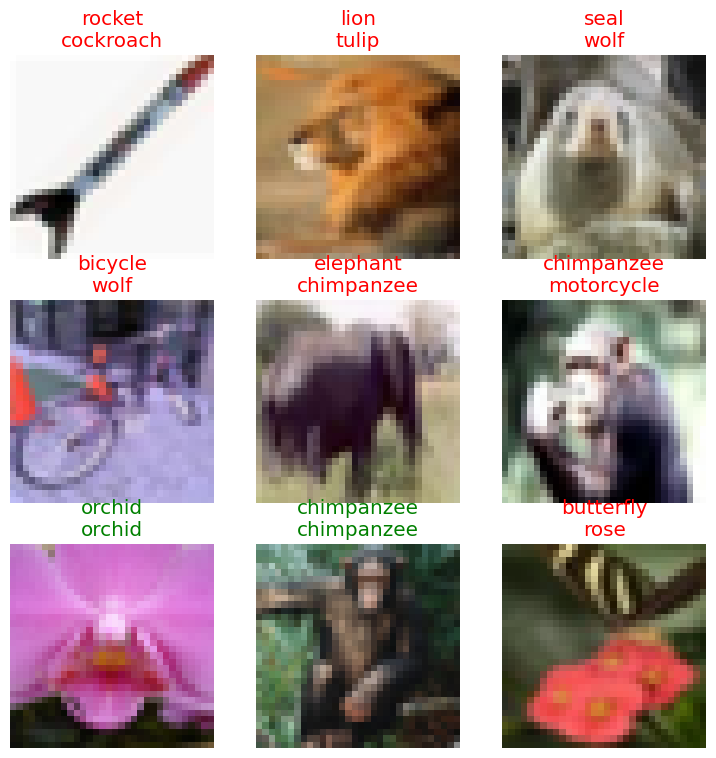

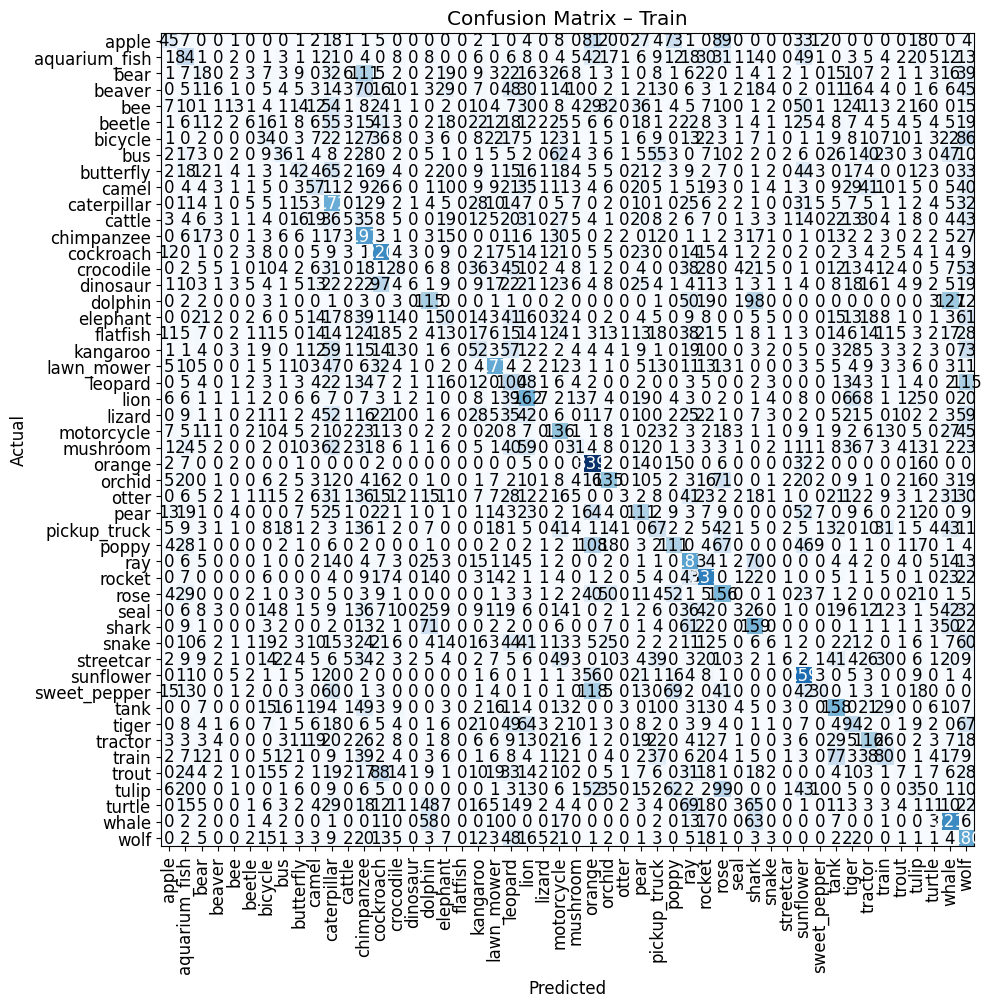

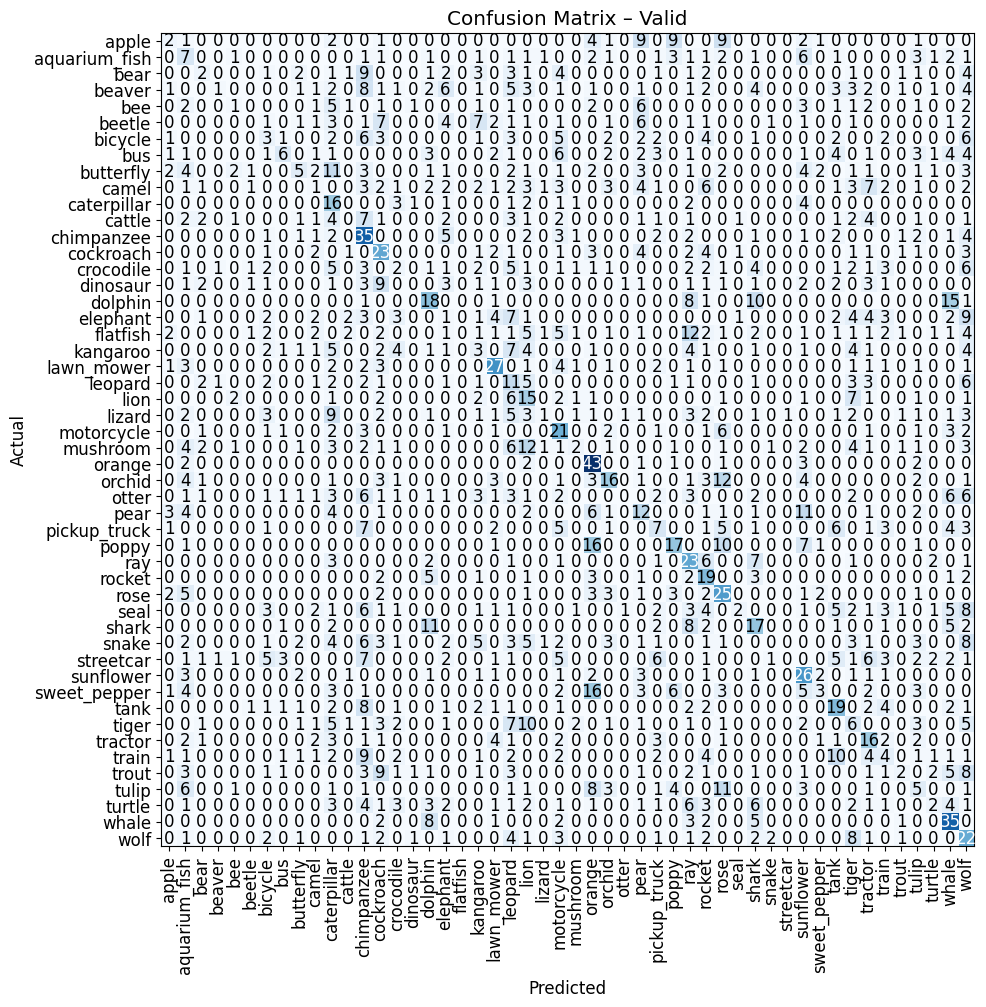

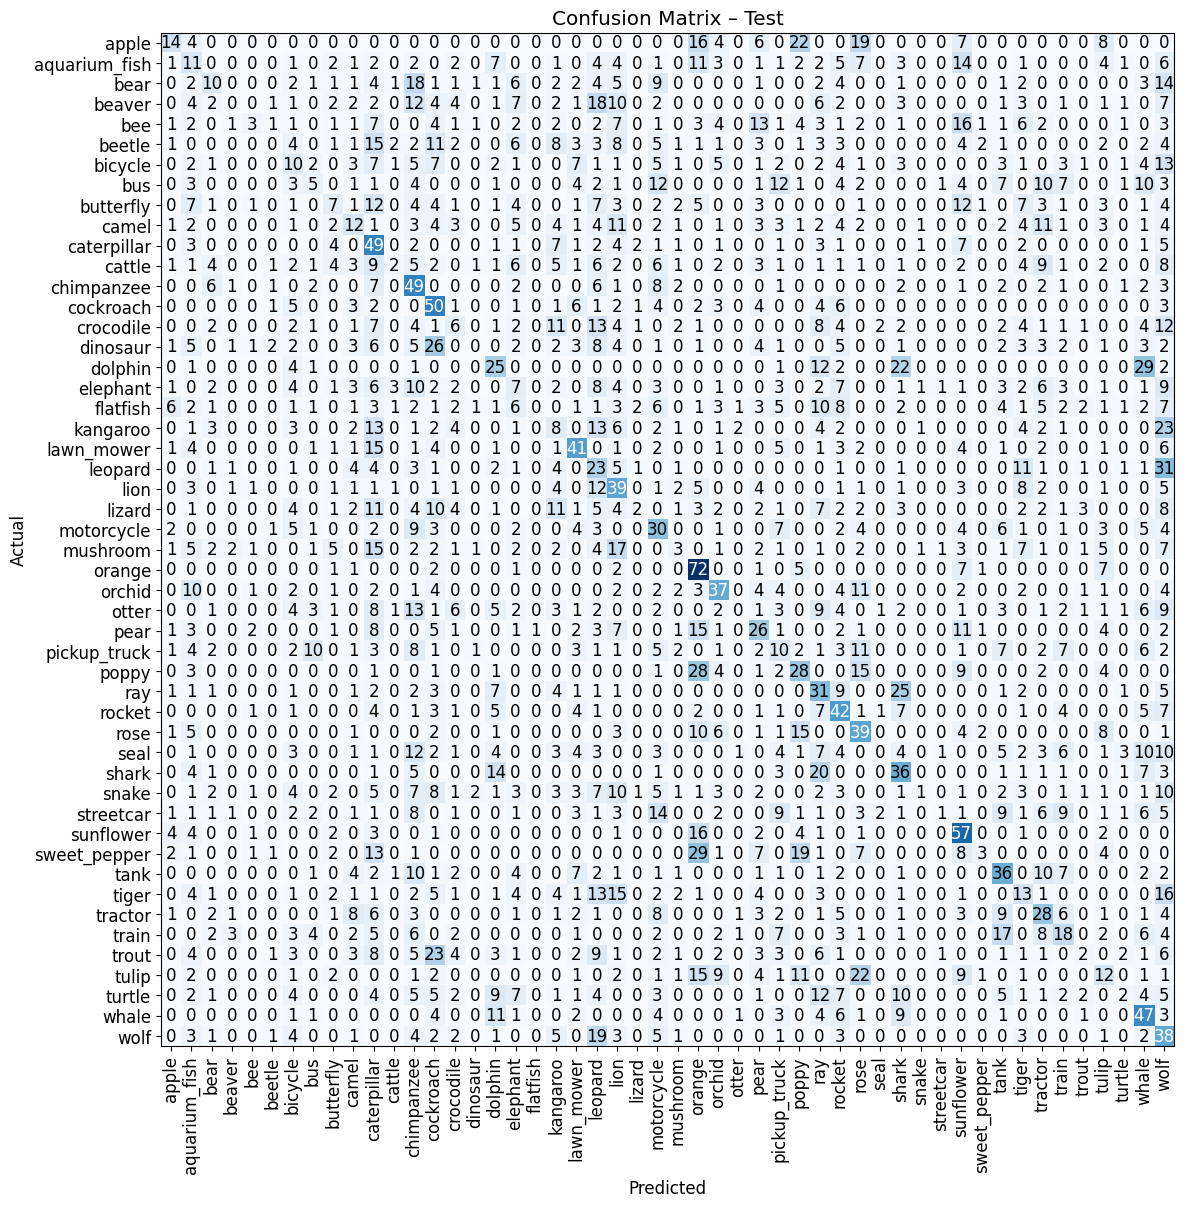

In [ ]:
# A CUBRIR POR EL ALUMNADO
learn_SinFC.show_results()

test_dl = dls.test_dl(get_image_files(path/'test'), with_labels=True)
loss_tr, acc_tr, f1_tr = learn_SinFC.validate(dl=dls.train)
loss_va, acc_va, f1_va = learn_SinFC.validate(dl=dls.valid)
loss_te, acc_te, f1_te = learn_SinFC.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  acc {acc_tr:.4f}  F1 {f1_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  acc {acc_va:.4f}  F1 {f1_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  acc {acc_te:.4f}  F1 {f1_te:.4f}")

# We compute the confusion matrix
from fastai.interpret import ClassificationInterpretation
interp_tr = ClassificationInterpretation.from_learner(learn_SinFC, dl=dls.train)
interp_tr.plot_confusion_matrix(figsize=(10,10), title='Confusion Matrix – Train')

interp_va = ClassificationInterpretation.from_learner(learn_SinFC, dl=dls.valid)
interp_va.plot_confusion_matrix(figsize=(10,10), title='Confusion Matrix – Valid')

interp_te = ClassificationInterpretation.from_learner(learn_SinFC, dl=test_dl)
interp_te.plot_confusion_matrix(figsize=(12,12), title='Confusion Matrix – Test')

<font color='blue'>**Evaluación del rendimiento**

<font color='blue'>Podemos ver en test y validación obtiene resultados similares, aproximadamente accuracy de en test acc 0.197 y de 0.209 en validación y F1 de en test 0.158 y de 0.164 en validación. Son resultados algo peores que BaseNet, que usabamos Fully Connected layers, sin embargo , ahora practicamente ha desaparecido el sobreajuste, por lo que podemos decir que generaliza mejor. Ambos resultados son esperados con el cambio en la arquitectura.

<font color='blue'>Por otro lado analizando la evolución de las métricas durante las distintas época, podemos observar que inicialmente el modelo es prácticamente aleatorio pero conforme van avanzando las época el modelo e va actualizando y va aprendiendo cada vez mejor.

#  **Ejercicio 2:** **Mejoras sobre el modelo BaseNet (4 puntos)**
Ahora el objetivo es crear una versión mejorada del modelo _BaseNet_ (implementado en el primer apartado del ejercicio anterior). Para ello, se puede experimentar con distintas funciones de activación, funciones de pérdida, una mayor o menor profundidad de la red, un mayor o menor número de filtros por bloque convolucional, y/o diferentes técnicas de regularización u optimización, entre otras. De hecho, los alumnos deben sentirse libres para experimentar e incorporar todas las modificaciones que consideren pertinentes, incluyendo elementos no vistos ni en teoría ni en prácticas (por ejemplo, componentes que hayan podido descubrir a través de la revisión de artículos científicos) u otros más sencillos y directos (como entrenar por más épocas). **Se valorará la originalidad y complejidad de la propuesta realizada.**

Es necesario destacar que **es imprescindible justificar de la mejor forma posible las decisiones tomadas** (ya sea mediante evidencia empírica o mediante literatura científica), **así como el rendimiento obtenido** (esto es, intentar explicar qué es lo que hace que mejoren los resultados; desde este punto de vista, es importante moverse de la mera constatación al intento de explicación). También es importante remarcar que **las mejoras introducidas, dentro de lo posible, deben realizarse de forma incremental**, es decir, no basta con crear directamente (de forma "mágica") un único modelo y evaluarlo:  **es necesario justificar y describir qué pasos y resultados intermedios nos han llevado a diseñar ese modelo concreto**. Se debe describir cada una de las mejoras incorporadas, así como analizar los resultados obtenidos (del mismo modo que se hizo en el Ejercicio 1), y se debe emplear  un $10\%$ de los ejemplos de entrenamiento para validación. También es necesario, al igual que en el Ejercicio 1, desglosar el número de parámetros del modelo final, y se debe hacer un `summary()` del modelo para verificar que la arquitectura se ha construido correctamente y que el número de parámetros se corresponde con lo esperado.  

Como referencia para los estudiantes, se espera que la _accuracy_ en validación alcance, como mínimo, el $65\%$.


<font color='blue'>**Partimos de los siguientes resultados:**

<font color='blue'>Train - loss 1.0920 acc 0.6855 F1 0.6812

<font color='blue'>Valid - loss 2.6430 acc 0.3444 F1 0.3363

<font color='blue'>Test - loss 2.5650 acc 0.3616 F1 0.3545

<font color='blue'>Tiempo: 7 minutos

<font color='blue'>Vamos a empezar sustituyendo las **funciones de activación** Sigmoid y Tanh por ReLU, ya que aunque tradicionalmente se usaban funciones de activación sigmoides, ahora se recomienda para deep networks usar ReLU entre otras cosas porque permite un entrenamiento más rápido. Resultados:

<font color='blue'>Train  - loss 0.6772  acc 0.7913  F1 0.7916

<font color='blue'>Valid  - loss 3.4162  acc 0.3212  F1 0.3227

<font color='blue'>Test   - loss 3.3368  acc 0.3230  F1 0.3259

<font color='blue'>Tiempo: 5 minutos: No improvement since epoch 8: early stopping

<font color='blue'>Podemos ver que en validación y test no mejoran los resultados, de hecho empeoran ligeramente pero en cambio en training el accuracy sube a casi un 80% igual que F1, lo que indicar una gran cantidad de sobreajuste.

<font color='blue'>Para intentar reducir el sobreajuste vamos a vamos a usar **BatchNormalization**, ya que normalizar la entrada acelera el entrenamiento además de introducir un efecto de regularización. Lo que vamos a hacer es normalizar las entradas a las capas ocultas(justo antes de aplicar la función de activación). Resultados:

<font color='blue'>Train  - loss 0.4441  acc 0.8726  F1 0.8728

<font color='blue'>Valid  - loss 2.9598  acc 0.3708  F1 0.3692

<font color='blue'>Test   - loss 2.9716  acc 0.3748  F1 0.3718

<font color='blue'>Tiempo: 5 minutos, No improvement since epoch 11: early stopping

<font color='blue'>Han mejorado tanto el entrenamiento como validación y test pero seguimos teniendo un montón de sobreajuste.

<font color='blue'>Por ello vamos a realizar **DataAugmentation**, que consiste en aplicar diferentes transformaciones a la entrada, con do_flip=True aplica un giro horizontal con una probabilidad de $0.5$, el parámetro max_rotate expecifica el grado máximo de rotació, 10 en este caso, max_zoom define el factor máximo de zoom, en nuestro caso permitimos un zoom de 1.0 a 1.1, max_warp = 0.0 desactiva warping completamente, por último p_lighting indica la probabilidad de cambios en el brillo y contraste, en este caso un $50%$.Con esto también regularizamos y mejoramos la generalización. Resultados:

<font color='blue'>Train  - loss 1.4735  acc 0.5734  F1 0.5685

<font color='blue'>Valid  - loss 2.0790  acc 0.4348  F1 0.4276

<font color='blue'>Test   - loss 2.0562  acc 0.4326  F1 0.4268

<font color='blue'>Tiempo: 6 minutos, No improvement since epoch 11: early stopping

<font color='blue'>No solo han aumentado los resultados en validación y test sino que además se ha reducido considerablemente la diferencia con los resultados obtenidos en training.

<font color='blue'>Introducimos ahora **Dropout**, que de manera aleatoria elimina unidades ocultas durante el entrenamiento. Fuerza a la "generalización" de las unidades, desacoplandolas unas de las otras. Se aplica en general en las FC layers y con unidades diferentes en cada iteración. De acuerdo con *Park & Kwak. Analysis on the dropout effect in convolutional neural
networks* los mejores resultados se obtienen cuando $p < 0.5$. Resultados:

<font color='blue'>Train  - loss 1.5255  acc 0.5514  F1 0.5410

<font color='blue'>Valid  - loss 2.0534  acc 0.4404  F1 0.4279

<font color='blue'>Test   - loss 2.0304  acc 0.4358  F1 0.4239

<font color='blue'>Tiempo: 8 minutos, No improvement since epoch 17: early stopping

<font color='blue'>No ha mejorado en validación y test pero vemos que efectivamente ha reducido ligeramente el sobreajuste.

<font color='blue'>Ahora necesitamos subir el porcentaje en validación para llegar al 65%, para ello vamos a usar un optimizador distinto, en este caso **Adam**, que suele converger más rápido que SGD, especialmente en modelos complejos como redes neuronales profundas y transformers.

<font color='blue'>Como hemos visto, a diferencia de SGD, que utiliza una tasa de aprendizaje fija o programada, Adam ajusta la tasa de aprendizaje por parámetro. Esto le permite:

- <font color='blue'>dar pasos más grandes cuando los gradientes son ruidosos o dispersos,

- <font color='blue'>y pasos más pequeños y cautelosos al acercarse a un mínimo,
lo cual mejora la estabilidad y la velocidad de convergencia.
<font color='blue'> Además, Adam es especialmente eficaz clasificación de imágenes con CNNs, que es justo el problema al que nos enfrentamos.

<font color='blue'>Hay que tener en cuenta también que Adam generaliza peor, es decir, tiene peor rendimiento en datos no vistos, algo que se puede ver en los resultados.

<font color='blue'>Para compensar el ligero overfitting que introduce Adam, he incluido también **label smoothing cross entropy** que es una técnica de regularización diseñada para hacer que el modelo sea menos seguro de sus predicciones mediante la modificación de las etiquetas objetivo durante el entrenamiento.
En lugar de asignar una probabilidad de 1 a la clase correcta y 0 a todas las demás, el suavizado de etiquetas ajusta el objetivo para asignar una probabilidad de
1-𝜀 a la clase correcta y ε/N a cada una de las otras clases, donde 𝜀 es un número positivo pequeño y N es el número total de clases. Con esto reducimos el sobreajuste.

<font color='blue'>Train  - loss 1.8255  acc 0.5914  F1 0.5910

<font color='blue'>Valid  - loss 2.0004  acc 0.4604  F1 0.4449

<font color='blue'>Test   - loss 2.0004  acc 0.4488  F1 0.4419

<font color='blue'>A pesar del cambio de optimizador, la diferencia de subida sigue siendo mínima, por lo que quizás el problema no sea tanto lo parámetros, ya que además he estado probando a subir las época subiendo también ligeramente la paciencia o a modificar el learning rate partiendo del análisis obtenido de *lr_find()* y tampoco se han apreciando mejoras significativas. Incluso con actualizaciones de Adam como AdamW o StableAdam que no lo conocía pero según he leído se considera mejor que AdamW en ciertos escenarios porque resuelve problemas de inestabilidad que pueden aparecer durante el entrenamiento.

<font color='blue'>Por ello lo que he decidido es introducir **más capas convolucionales**, en concreto 2, y aumentando hasta 128 el número de canales, ya que como sabemos aumentar el número de canales permite detectar una variedad más amplia de características en la imagen. Este proceso permite que la red aprenda patrones más complejos, ya que cada canal representa una característica distinta detectada por un filtro específico.
Por ejemplo, si se aplican 32 filtros, el resultado será un mapa de características con 32 canales, cada uno destacando diferentes aspectos de la imagen original.

<font color='blue'>Simplemente con este cambio, ya he aumentado un 10% en validación, evidentemente hay que ajustar las capas lineales y los BatchNormalization para que funcione correctamente.

<font color='blue'>Mirando el summary() de la red, un detalle que me he dado cuenta, es que tengo una cantidad enorme de parámetros, de varios millones, y quizas en un dataset que las imágenes son de tamaño pequeño en comparación por ejemplo a las de los ejercicios 3 y 4 y que tiene 50 clases, quizás son muchos. Por ello he reducido considerablemente el número introduciendo dos nn.MaxPool2d(2) pasando de la imagen 32x32 a una 16x16 después de dos convoluciones, después a 8x8 trs otras dos convoluciones y po último a 4x4 tras unas últimas dos convoluciones. Otro aspecto a destacar y que también me parece muy significativo, es que he visto que en los ejercicios 3 y 4 usamos kernel también 7x7, y las imágenes son mucho más grandes, luego tendría sentido aquí usar kernels de tamaño más pequeño, **kernels de 3x3** que además son astante estandar, ya que reduces así el sobreajuste y el tiempo de entrenamiento.

<font color='blue'>Con esto obtengo los siguientes resultados:

<font color='blue'>Train  - loss 1.5810  acc 0.7467  F1 0.7432

<font color='blue'>Valid  - loss 1.9374  acc 0.5892  F1 0.5861

<font color='blue'>Test   - loss 1.9287  acc 0.5932  F1 0.5902

<font color='blue'>Para terminar de subir en validación, he pasado de usar el método fit que usa una tasa de aprendizaje constante durante todo el proceso de entrenamiento,lo que puede conducir a una convergencia más lenta o a resultados menos precisos.

<font color='blue'>En contraste, **fit_one_cycle** implementa la política 1cycle, una técnica desarrollada por Leslie Smith que utiliza tasas de aprendizaje cíclicas que varían durante un único ciclo.
Esta política comienza con una tasa de aprendizaje baja, la incrementa hasta un valor máximo elevado, y luego la reduce a un valor mucho menor que el inicial.
Este enfoque permite un fenómeno conocido como super-convergencia, que posibilita entrenar modelos significativamente más rápido y conseguir mayor precisión en comparación con los métodos tradicionales.

<font color='blue'>Con estos cambios obtengo los resultados finales de:

<font color='blue'>Train  - loss 1.2510  acc 0.8681  F1 0.8674

<font color='blue'>Valid  - loss 1.7720  acc 0.6580  F1 0.6534

<font color='blue'>Test   - loss 1.7797  acc 0.6532  F1 0.6504

<font color='blue'>**Desglose del número de parámetros del modelo final**

<font color='blue'>Fórmula general para capas convolucionales:

<font color='blue'>Dado un tamaño de kernel k, número de canales de entrada in y de salida out:

- <font color='blue'>parámetros por filtro = k * k * in + 1

- <font color='blue'>total parámetros de la capa = parámetros por filtro * out

----------

<font color='blue'>Capa Conv1: Conv2d(3, 32, kernel_size=3)

- <font color='blue'>parámetros por filtro = 3 * 3 * 3 + 1 = 27 + 1 = 28
- <font color='blue'>total parámetros = 28 * 32 = 896

---------------

<font color='blue'>Capa Conv2: Conv2d(32, 32, kernel_size=3)

- <font color='blue'>parámetros por filtro = 3 * 3 * 32 + 1 = 288 + 1 = 289
- <font color='blue'>total parámetros = 289 * 32 = 9.248

--------------

<font color='blue'>Capa Conv3: Conv2d(32, 64, kernel_size=3)

- <font color='blue'>parámetros por filtro = 3 * 3 * 32 + 1 = 289
- <font color='blue'>total parámetros = 289 * 64 = 18.496

---------------

<font color='blue'>Capa Conv4: Conv2d(64, 64, kernel_size=3)

- <font color='blue'>parámetros por filtro = 3 * 3 * 64 + 1 = 576 + 1 = 577
- <font color='blue'>total parámetros = 577 * 64 = 36.928

<font color='blue'>Capa Conv5: Conv2d(64, 128, kernel_size=3)

- <font color='blue'>parámetros por filtro = 3 * 3 * 64 + 1 = 577
- <font color='blue'>total parámetros = 577 * 128 = 73.856

<font color='blue'>Total parámetros convolucionales:

<font color='blue'>Suma capas convolucionales = 896 + 9.248 + 18.496 + 36.928 + 73.856 = 139.424

------------

<font color='blue'>Batch Normalization

<font color='blue'>Cada capa BatchNorm2d(C) tiene 2*C parámetros entrenables (gamma y beta).

- <font color='blue'>BatchNorm2d(32): 2 * 32 = 64 parámetros (hay 2 capas)
Total BN con 32 canales = 2 * 64 = 128

- <font color='blue'>BatchNorm2d(64) → 2 * 64 = 128 parámetros (hay 2 capas)
Total BN con 64 canales = 2 * 128 = 256

- <font color='blue'>BatchNorm2d(128): 2 * 128 = 256 parámetros

<font color='blue'>Total BN = 128 + 256 + 256 = 640

----------------

<font color='blue'>Fórmula general para capas fully connected:

<font color='blue'>Para una capa densa con n_in unidades de entrada y n_out de salida:

<font color='blue'>Parámetros = (n_in * n_out) + n_out

<font color='blue'>FC1: Linear(2048, 256)

<font color='blue'>La entrada a esta capa es el tensor 128 x 4 x 4, es decir:

<font color='blue'>n_in = 128 * 4 * 4 = 2048
<font color='blue'>n_out = 256

<font color='blue'>Parámetros FC1 = 2048 * 256 + 256 = 524.288 + 256 = 524.544

<font color='blue'>FC2: Linear(256, 50)
<font color='blue'>n_in = 256
<font color='blue'>n_out = 50

<font color='blue'>Parámetros FC2 = 256 * 50 + 50 = 12.800 + 50 = 12.850

------------------

<font color='blue'>**Total parámetros del modelo = 139.424 + 640 + 524.544 + 12.850 = 677.458**


Numero de ejemplos de entrenamiento (una vez descartados los de validacion): 22500
Numero de ejemplos de validacion: 2500


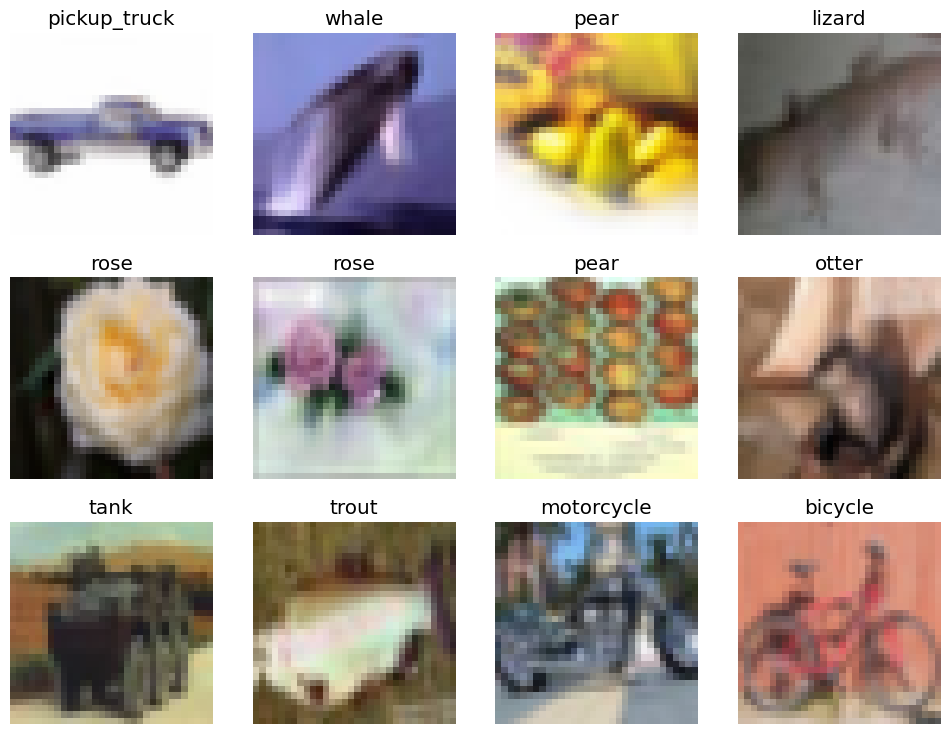

In [ ]:
cifar_mean = (0.5071,0.4865,0.4409)
cifar_std  = (0.2673,0.2564,0.2762)

CIFAR_50_definitivo = DataBlock(
    # A CUBRIR POR EL ALUMNADO
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.1, seed=42), #10% of the training set will be used for validation
    get_y=parent_label,
    item_tfms = Resize(32),
    batch_tfms = [IntToFloatTensor(),
                    *aug_transforms(do_flip=True, max_rotate=10, max_zoom=1.1,
                                      max_warp=0.0, p_lighting=0.5),
                    Normalize.from_stats(cifar_mean, cifar_std)]
    #batch_tfms = [IntToFloatTensor()]
)

dls_definitivo = CIFAR_50_definitivo.dataloaders(path/'train',batch_size=128)

dls_definitivo.show_batch(max_n=12)

print('Numero de ejemplos de entrenamiento (una vez descartados los de validacion):', len(dls_definitivo.train_ds))
print('Numero de ejemplos de validacion:', len(dls_definitivo.valid_ds))

In [ ]:
# A CUBRIR POR EL ALUMNADO
from torch import nn
import torch.nn.functional as F

# BaseNet_Definitiva = nn.Sequential(
#     # A CUBRIR POR EL ALUMNADO
#     nn.Conv2d(3, 10, kernel_size=7, stride=1, padding=3),
#     nn.BatchNorm2d(10),
#     nn.ReLU(),
#     nn.MaxPool2d(2),

#     nn.Conv2d(10, 15, kernel_size=7, stride=1, padding=0),
#     nn.BatchNorm2d(15),
#     nn.ReLU(),

#     nn.Flatten(),
#     nn.Linear(1500, 750),
#     nn.ReLU(),
#     nn.Dropout(p=0.4),
#     nn.Linear(750, 150),
#     nn.ReLU(),
#     nn.Linear(150, 50)
# )

BaseNet_Definitiva = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),          #32 x 16 x 16

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),  #64x8x8

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2), #128x4x4

    nn.Flatten(),             # 128 * 4 * 4 = 2048
    nn.Linear(128*4*4, 256),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(256, 50)
)

BaseNet_Definitiva

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): BatchNorm2d(128, eps=1e-05, momentum=0.1, 

In [ ]:
from fastai.vision.models.xresnet import xresnet18
from torch import nn

# modelo con bloques residuales y cabeza a 50 clases
#BaseNet_Definitiva = xresnet18(c_in=3, n_out=50, act_cls=nn.ReLU)

In [ ]:
!pip install fastxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 5.7 MB/s eta 0:00:00


In [ ]:
#opt_func = partial(SGD, mom=0.9)
opt_func = Adam
#from fastxtend.optimizer.all import *

# Use StableAdamW with fused ForEach implementation
#opt_func = stableadam(foreach=True, decouple_wd=True)

learn_Definitivo = Learner(
    dls=dls_definitivo,
    model=BaseNet_Definitiva,
    #loss_func=CrossEntropyLossFlat(),
    loss_func=LabelSmoothingCrossEntropy(),
    opt_func=opt_func,
    cbs=[
        EarlyStoppingCallback(monitor='valid_loss', patience=8),
    ],
    metrics=[accuracy, F1Score(average='macro')],
)

In [ ]:
learn_Definitivo.summary()

Sequential (Input shape: 128 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 32 x 32 x 32  
Conv2d                                    896        True      
BatchNorm2d                               64         True      
ReLU                                                           
Conv2d                                    9248       True      
BatchNorm2d                               64         True      
ReLU                                                           
____________________________________________________________________________
                     128 x 32 x 16 x 16  
MaxPool2d                                                      
____________________________________________________________________________
                     128 x 64 x 16 x 16  
Conv2d                                    18496      True      
BatchNorm2d                               128        True      
ReLU                                

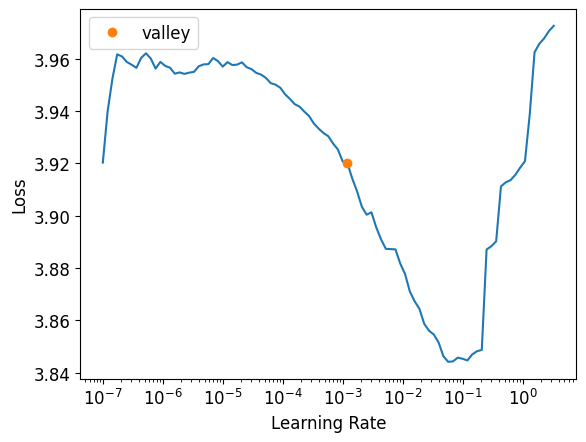

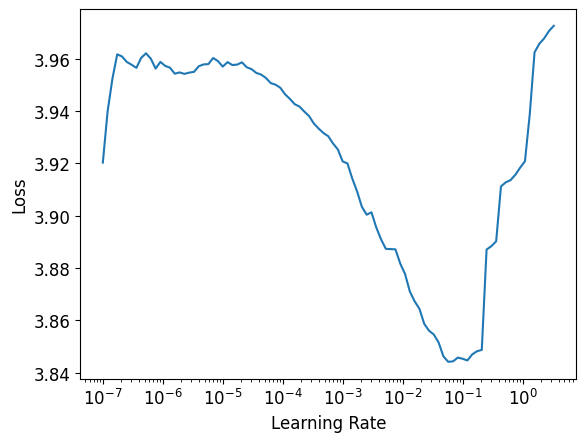

In [ ]:
learn_Definitivo.lr_find()
learn_Definitivo.recorder.plot_lr_find()


<font color='blue'>Escogemos como learning rate cuando la pérdida empieza a bajar rápido, y antes de que se dispare hacia arriba.

In [ ]:
learn_Definitivo.fit_one_cycle(40, lr_max=0.003)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.513514,3.242999,0.180800,0.154949,00:22
1,3.251103,3.054217,0.240000,0.222415,00:20
2,3.087655,2.823505,0.302800,0.277023,00:22
3,2.998453,2.810846,0.303200,0.284487,00:21
4,2.959764,2.692320,0.334800,0.314499,00:23
5,2.921726,2.634964,0.355200,0.334260,00:22
6,2.881210,2.600102,0.370000,0.345401,00:31
7,2.813092,2.460794,0.418400,0.406579,00:25
8,2.728340,2.353734,0.456400,0.445351,00:28
9,2.647144,2.362467,0.446400,0.439431,00:30


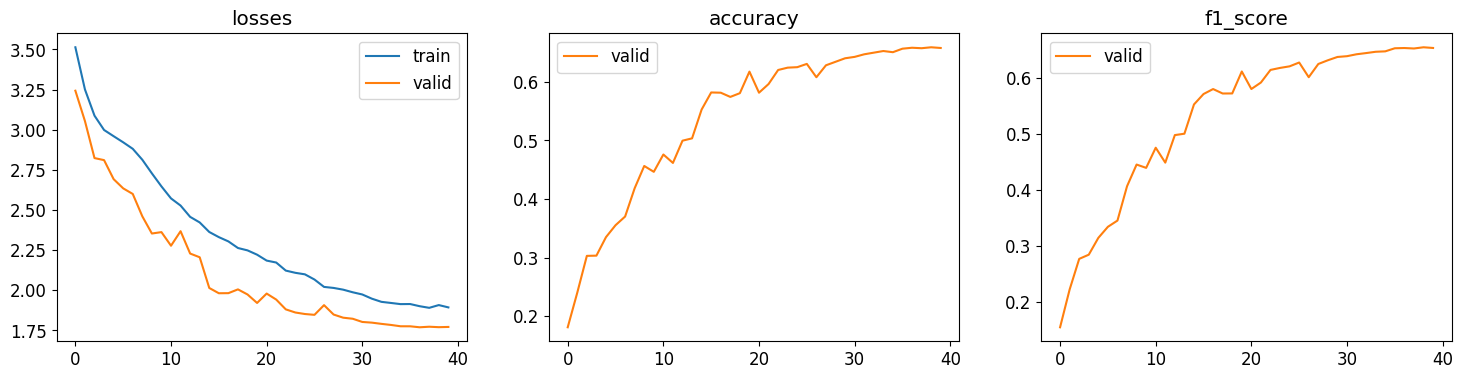

In [ ]:
learn_Definitivo.recorder.plot_metrics()

Train  - loss 1.2510  acc 0.8681  F1 0.8674
Valid  - loss 1.7720  acc 0.6580  F1 0.6534
Test   - loss 1.7797  acc 0.6532  F1 0.6504


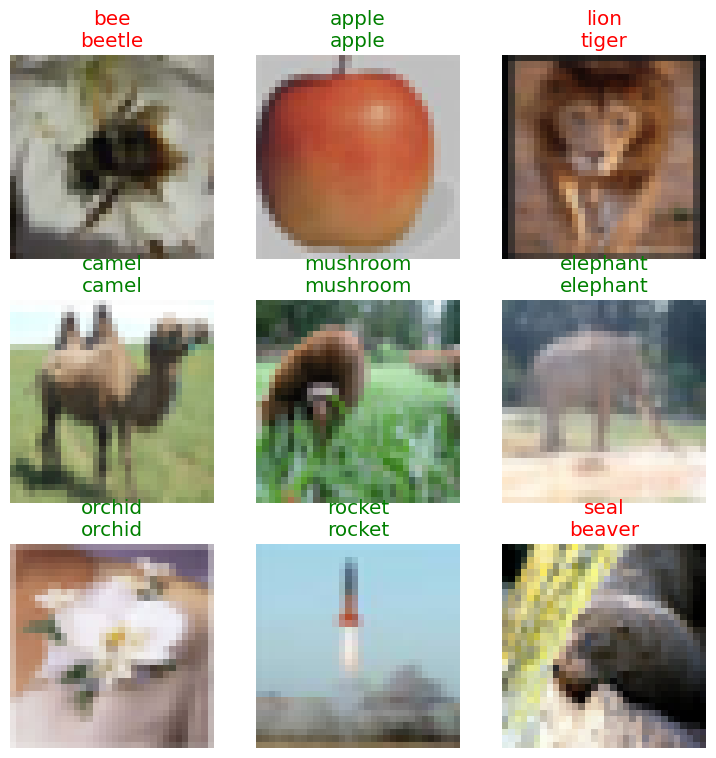

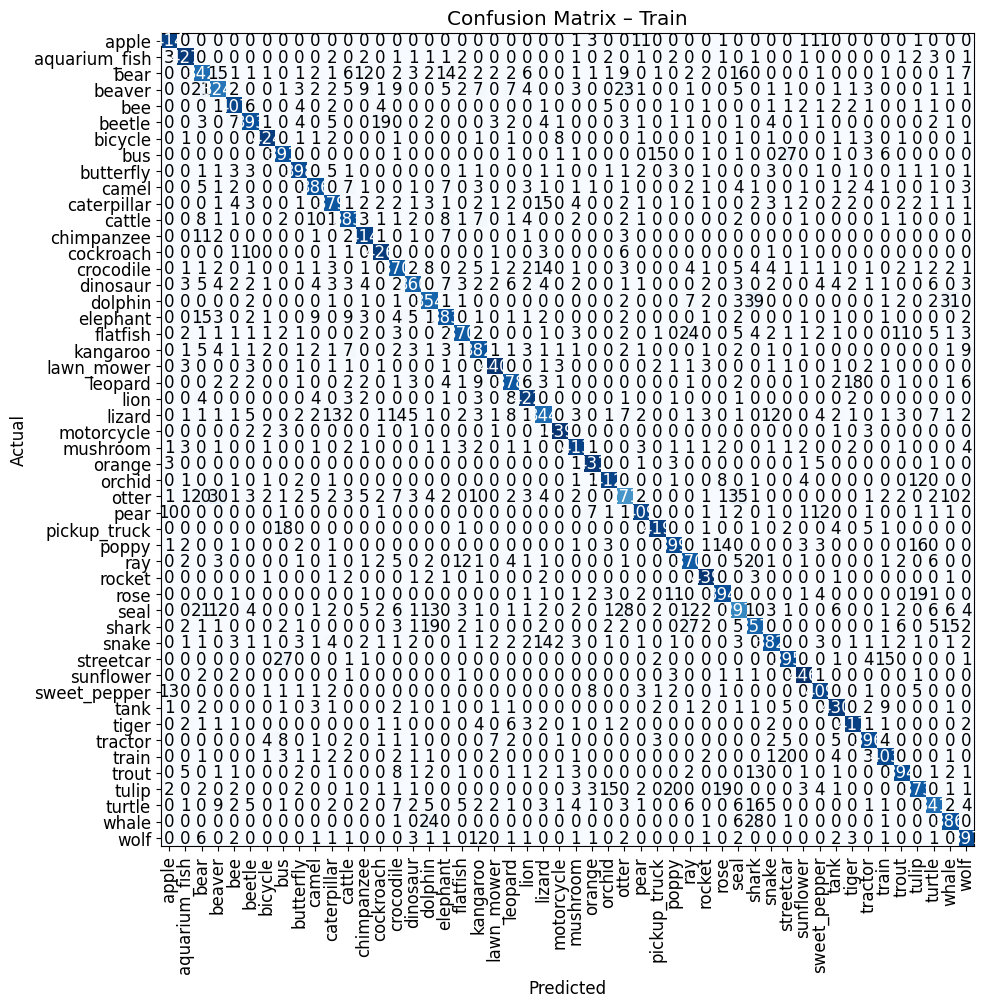

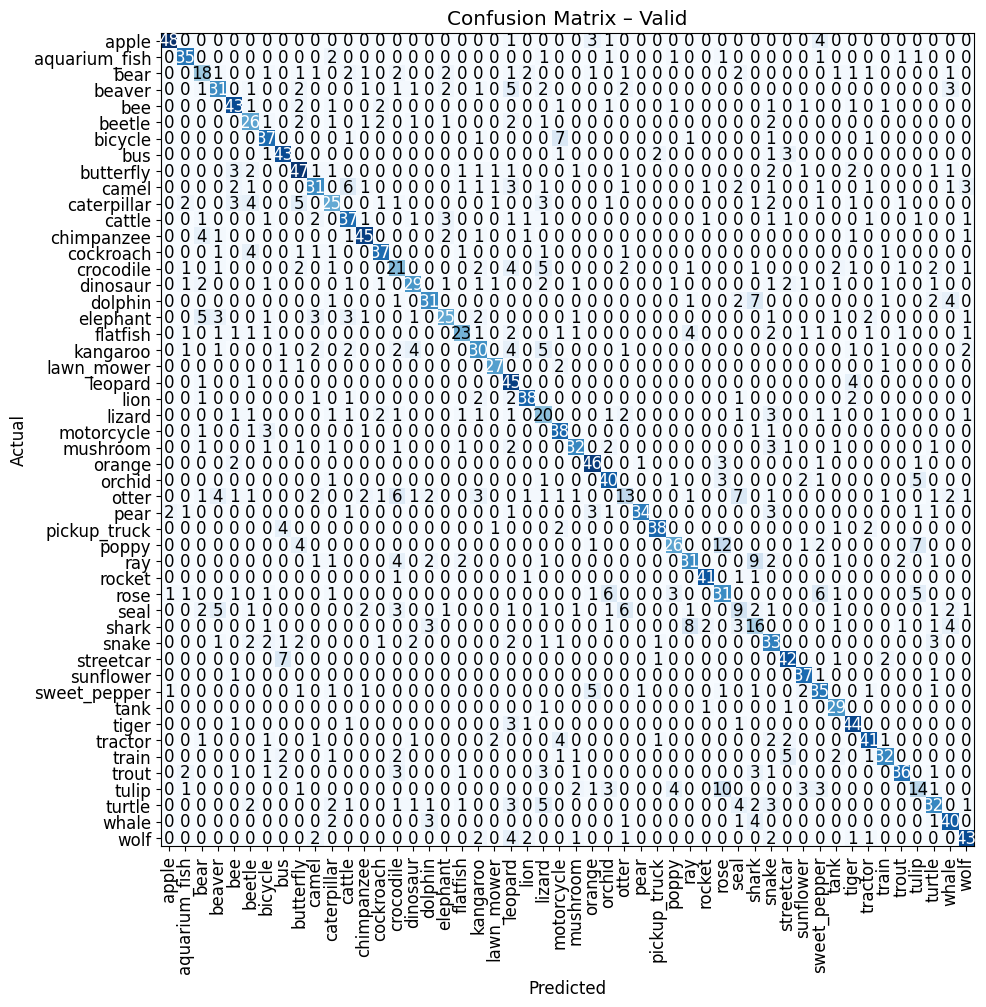

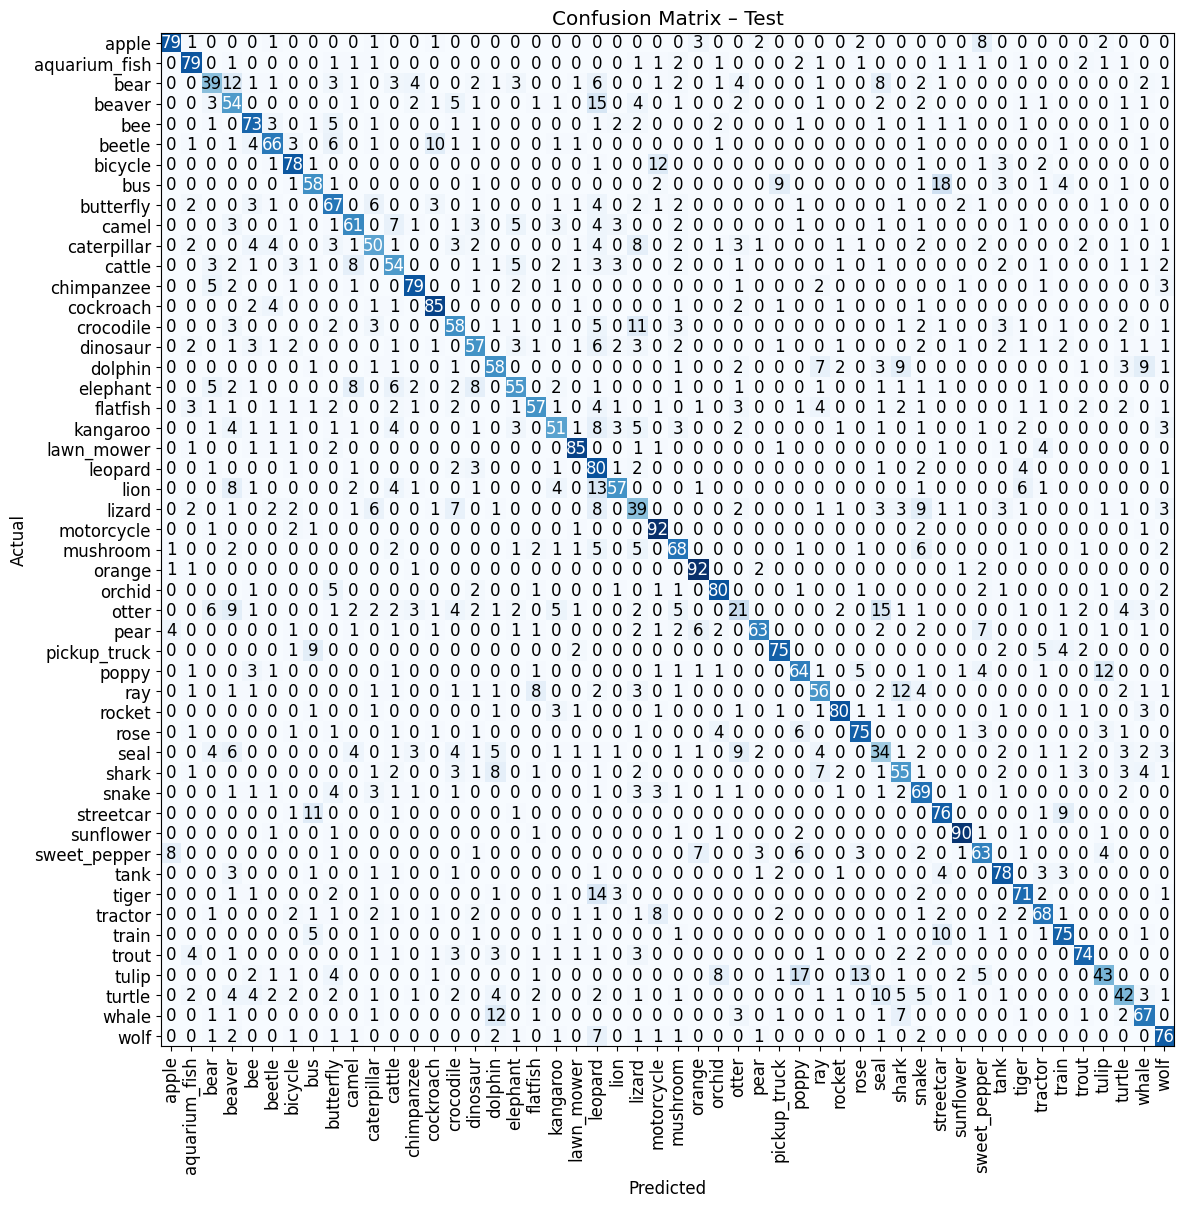

In [ ]:
# A CUBRIR POR EL ALUMNADO
learn_Definitivo.show_results()

test_dl = dls_definitivo.test_dl(get_image_files(path/'test'), with_labels=True)
loss_tr, acc_tr, f1_tr = learn_Definitivo.validate(dl=dls_definitivo.train)
loss_va, acc_va, f1_va = learn_Definitivo.validate(dl=dls_definitivo.valid)
loss_te, acc_te, f1_te = learn_Definitivo.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  acc {acc_tr:.4f}  F1 {f1_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  acc {acc_va:.4f}  F1 {f1_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  acc {acc_te:.4f}  F1 {f1_te:.4f}")

# We compute the confusion matrix
from fastai.interpret import ClassificationInterpretation
interp_tr = ClassificationInterpretation.from_learner(learn_Definitivo, dl=dls_definitivo.train)
interp_tr.plot_confusion_matrix(figsize=(10,10), title='Confusion Matrix – Train')

interp_va = ClassificationInterpretation.from_learner(learn_Definitivo, dl=dls_definitivo.valid)
interp_va.plot_confusion_matrix(figsize=(10,10), title='Confusion Matrix – Valid')

interp_te = ClassificationInterpretation.from_learner(learn_Definitivo, dl=test_dl)
interp_te.plot_confusion_matrix(figsize=(12,12), title='Confusion Matrix – Test')

<font color='blue'>**Análisis de resultados**

<font color='blue'>Los resultados finales obtenidos con el modelo BaseNet_Definitiva son: Train - loss 1.2510, acc 0.8681, F1 0.8674; Valid - loss 1.7720, acc 0.6580, F1 0.6534; Test - loss 1.7797, acc 0.6532, F1 0.6504. Estos valores muestran que el modelo aprende muy bien sobre el conjunto de entrenamiento (alrededor de un 87% de acierto) y generaliza razonablemente bien a validación y test, donde la accuracy se sitúa en torno al 65%, superando el umbral exigido en el enunciado.

<font color='blue'>En la gráfica de pérdidas se observa que tanto la loss de entrenamiento como la de validación descienden de forma monótona desde valores iniciales cercanos a 3.5 hasta estabilizarse, al final del entrenamiento, alrededor de 1.8-1.9. Esta caída sostenida indica que el modelo va aprendiendo patrones útiles y que no se queda estancado en un comportamiento aleatorio. Además, las dos curvas se mantienen relativamente próximas durante todo el entrenamiento, lo que sugiere que la regularización está funcionando y que de hecho hay underfitting.

<font color='blue'>Las curvas de accuracy y F1 score en validación muestran una subida rápida en las primeras épocas (hasta aproximadamente 0.45) y una fase posterior de crecimiento más lento, hasta alcanzar valores cercanos a 0.66 hacia las últimas épocas. A partir de ese punto ambas métricas entran en una especie de meseta, en la que las mejoras son ya muy pequeñas. Esto indica que el número de épocas utilizado es adecuado: el modelo aprovecha prácticamente todo el entrenamiento y no parece que seguir entrenando vaya a producir mejoras significativas.

<font color='blue'>Un aspecto importante es que los resultados sobre el conjunto de test (acc ≈ 0.653, F1 ≈ 0.650) son prácticamente idénticos a los de validación. Esto es una muy buena señal, ya que indica que el modelo no se ha “ajustado” específicamente al conjunto de validación, sino que mantiene un rendimiento similar cuando se evalúa sobre datos completamente nuevos.

<font color='blue'>La diferencia entre la loss de entrenamiento que aparece en la gráfica (alrededor de 1.8-1.9) y la loss de entrenamiento obtenida con la llamada a validate (1.2510) se debe a cómo se calculan ambas. Durante el entrenamiento, la curva azul de “train” se obtiene con el modelo en modo entrenamiento, aplicando data augmentation y dropout, lo que introduce ruido y hace que la pérdida sea más alta.

<font color='blue'>En cambio, cuando se llama a learn_Definitivo.validate(dl=dls_definitivo.train), el modelo se pone en modo evaluación (eval): se desactivan tanto dropout como data augmentation y BatchNorm utiliza sus estadísticas fijas. En estas condiciones el modelo es más “seguro” en sus predicciones y la loss sobre el mismo conjunto de entrenamiento resulta bastante menor (1.2510). Por tanto, no hay contradicción entre la gráfica y los resultados de validate, sino dos formas distintas de medir el rendimiento del modelo sobre los datos de entrenamiento.